In [1]:
# ----------------------------------------------------------------------
# 讀取地震目錄並顯示台灣時間前 20 大排行榜
# ----------------------------------------------------------------------
import glob
from IPython.display import display
import pandas as pd

catalog_files = glob.glob("GDMScatalog*.csv")
catalog_file = (
    "GDMScatalog_3.csv"
    if "GDMScatalog_3.csv" in catalog_files
    else catalog_files[0]
)

df_catalog = pd.read_csv(catalog_file, encoding="utf-8-sig")
df_catalog.columns = df_catalog.columns.str.strip()

# 轉換時間為台灣時間 (UTC+8)
df_catalog["dt_utc"] = pd.to_datetime(
    df_catalog["date"].astype(str) + " " + df_catalog["time"].astype(str),
    errors="coerce",
)
df_catalog["dt_local"] = df_catalog["dt_utc"] + pd.Timedelta(hours=8)

df_top20 = df_catalog.sort_values(by="ML", ascending=False).head(20).copy()
df_top20.reset_index(drop=True, inplace=True)
df_top20.index = df_top20.index + 1

df_top20_display = pd.DataFrame(
    {
        "日期": df_top20["dt_local"].dt.strftime("%Y-%m-%d"),
        "當地時間": df_top20["dt_local"].dt.strftime("%H:%M:%S.%f").str[:-4],
        "規模(ML)": df_top20["ML"],
        "緯度(°N)": df_top20["lat"],
        "經度(°E)": df_top20["lon"],
        "深度(km)": df_top20["depth"],
    }
)

print(
    f"📊 地震目錄（{catalog_file}）規模前 20 大地震排行榜 (台灣時間 UTC+8)："
)
display(df_top20_display)

📊 地震目錄（GDMScatalog.csv）規模前 20 大地震排行榜 (台灣時間 UTC+8)：


,日期,當地時間,規模(ML),緯度(°N),經度(°E),深度(km)
1,2024-04-03,07:58:09.94,7.19,23.8757,121.5735,19.72
2,2009-12-19,21:02:16.34,6.92,23.7880,121.6633,43.78
3,2022-09-18,14:44:15.25,6.83,23.1370,121.1958,7.81
4,2022-03-23,01:41:38.85,6.70,23.3985,121.6118,25.73
5,2022-09-17,21:41:19.11,6.60,23.0840,121.1608,8.61
6,2016-02-06,03:57:26.08,6.60,22.9220,120.5438,14.64
7,2024-04-03,08:11:26.39,6.56,24.1300,121.6513,13.44
8,2021-10-24,13:11:34.67,6.54,24.5333,121.7752,65.60
9,2022-12-15,12:03:16.42,6.51,23.7787,121.8450,16.30
10,2013-06-02,13:43:03.21,6.48,23.8615,120.9742,14.54


In [5]:
# ----------------------------------------------------------------------
# 地震水文分析共用工具庫
# ----------------------------------------------------------------------
import glob
from IPython.display import display
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# 1. 繪圖環境與表格對齊設定
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "Arial"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.unicode.east_asian_width", True)

# 2. 6 測站座標資訊
STATIONS_INFO = {
    "HWA": {"name": "花蓮", "lat": 23.9754, "lon": 121.6133},
    "TUN": {"name": "壯圍(宜蘭)", "lat": 24.7437, "lon": 121.7896},
    "DON": {"name": "東和(雲林)", "lat": 23.6849, "lon": 120.5699},
    "LIU": {"name": "六甲(台南)", "lat": 23.2254, "lon": 120.3506},
    "NAB": {"name": "那菝(台南)", "lat": 23.0691, "lon": 120.3487},
    "CHI": {"name": "赤山(屏東)", "lat": 22.5924, "lon": 120.6144},
}


def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(np.radians(lat1))
        * np.cos(np.radians(lat2))
        * np.sin(dlon / 2) ** 2
    )
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))


def get_event_by_rank(rank=1):
    eq = (
        df_catalog.sort_values(by="ML", ascending=False)
        .reset_index(drop=True)
        .iloc[rank - 1]
    )
    dists = {
        code: haversine(eq["lat"], eq["lon"], info["lat"], info["lon"])
        for code, info in STATIONS_INFO.items()
    }
    return {
        "time": eq["dt_local"],
        "mag": eq["ML"],
        "date_str": eq["dt_local"].strftime("%Y%m%d"),
        "dists": dists,
    }


def plot_seismic_event(
    rank=1,
    feature="water_level",
    mode="zoom",
    window_min=10,
    target_station=None,
    calc_stats=False,
):
    event = get_event_by_rank(rank)
    eq_time, eq_mag, date_str = (
        event["time"],
        event["mag"],
        event["date_str"],
    )

    feature_cfg = {
        "water_level": {
            "cols": ["WaterLevel"],
            "unit": "cm",
            "name": "水位",
            "stat_name": "地下水位同震波幅",
            "color": "#1f77b4",
            "clean": lambda x: None if x >= 9000 or x <= -9000 else x,
        },
        "pressure": {
            "cols": ["Atmospheric pressure", "Atmospheric Pressure"],
            "unit": "hPa",
            "name": "大氣壓力",
            "stat_name": "大氣壓力波動",
            "color": "#2ca02c",
            "clean": lambda x: None if x >= 9000 or x <= 0 else x,
        },
        "upper_temp": {
            "cols": ["Upper Temperature", "Upper_Temperature", "Temperature"],
            "unit": "°C",
            "name": "水溫",
            "stat_name": "水溫波動",
            "color": "#ff7f0e",
            "clean": lambda x: None if x >= 80 or x <= 0 else x,
        },
        "bottom_temp": {
            "cols": ["Bottom Temperature", "Bottom_Temperature"],
            "unit": "°C",
            "name": "下水溫",
            "stat_name": "下水溫波動",
            "color": "#d62728",
            "clean": lambda x: None if x >= 80 or x <= 0 else x,
        },
    }
    cfg = feature_cfg[feature]

    pattern = (
        f"*{date_str}*{target_station}*"
        if target_station
        else f"*{date_str}*"
    )
    files = sorted(
        [
            f
            for f in glob.glob(pattern)
            if not f.lower().endswith((".csv", ".ipynb"))
        ]
    )
    if not files:
        print(f"⚠️ 找不到對應 {date_str} 的測站資料檔！")
        return

    if mode == "day":
        t_start = pd.to_datetime(f"{eq_time.strftime('%Y-%m-%d')} 00:00:00")
        t_end = pd.to_datetime(f"{eq_time.strftime('%Y-%m-%d')} 23:59:59")
        padding = pd.Timedelta(minutes=30)
    else:
        t_start = eq_time - pd.Timedelta(minutes=window_min)
        t_end = eq_time + pd.Timedelta(minutes=window_min)
        padding = pd.Timedelta(seconds=0)

    results = []
    fig, axes = plt.subplots(
        len(files), 1, figsize=(12, 2.5 * len(files)), sharex=True
    )
    if len(files) == 1:
        axes = [axes]

    for i, file_path in enumerate(files):
        st_code = file_path.split(".")[1]
        st_name = STATIONS_INFO.get(st_code, {}).get("name", "")
        dist = event["dists"].get(st_code, 0.0)

        df = pd.read_csv(file_path)
        df["Time"] = pd.to_datetime(df["Time"])

        valid_col = None
        for c in cfg["cols"]:
            if c in df.columns:
                df[c] = df[c].apply(cfg["clean"])
                if df[c].notna().any():
                    valid_col = c
                    break

        sub = df[(df["Time"] >= t_start) & (df["Time"] <= t_end)]
        pre = df[
            (df["Time"] >= (eq_time - pd.Timedelta(minutes=5)))
            & (df["Time"] < eq_time)
        ]
        post_eq = sub[sub["Time"] >= eq_time]

        title = f"測站：{st_code} {st_name}（ 距震央 {dist:.1f} km ）"

        # 🔑 精簡圖例標籤，避免水平長度過長
        axes[i].axvline(
            eq_time,
            color="red",
            linestyle="--",
            linewidth=1.2,
            label=f"發震 ({eq_time.strftime('%H:%M:%S')})",
        )

        if valid_col and not sub[valid_col].dropna().empty:
            axes[i].plot(
                sub["Time"],
                sub[valid_col],
                label=f"{st_code} {cfg['name']}",
                color=cfg["color"],
                linewidth=1.0,
            )

            if calc_stats and not post_eq[valid_col].dropna().empty:
                v_pre = (
                    pre[valid_col].mean()
                    if (valid_col in pre and not pre[valid_col].dropna().empty)
                    else sub[valid_col].iloc[0]
                )
                v_max = post_eq[valid_col].max()
                v_min = post_eq[valid_col].min()
                amp = v_max - v_min
                dev_up = v_max - v_pre
                dev_down = v_min - v_pre

                results.append(
                    {
                        "測站代碼": st_code,
                        "測站名稱": st_name,
                        "距震央距離 (km)": round(dist, 1),
                        f"震前基準 ({cfg['unit']})": round(v_pre, 2),
                        f"最高 ({cfg['unit']})": round(v_max, 2),
                        f"最低 ({cfg['unit']})": round(v_min, 2),
                        f"最大全振幅 ({cfg['unit']})": round(amp, 2),
                        "最大向上偏移": round(dev_up, 2),
                        "最大向下偏移": round(dev_down, 2),
                    }
                )

                t_max = post_eq[post_eq[valid_col] == v_max]["Time"].iloc[0]
                t_min = post_eq[post_eq[valid_col] == v_min]["Time"].iloc[0]

                axes[i].plot(
                    t_max,
                    v_max,
                    "^",
                    color="red",
                    markersize=6,
                    label=f"Max: {v_max:.2f}",
                )
                axes[i].plot(
                    t_min,
                    v_min,
                    "v",
                    color="green",
                    markersize=6,
                    label=f"Min: {v_min:.2f}",
                )

            # 🔑 改為左上角 (upper left) 且分 2 欄 (ncol=2)，完全釋放右上方的震後波形與極值空間
            axes[i].legend(loc="upper left", ncol=2, frameon=True, framealpha=0.8, fontsize=8.5)
        else:
            axes[i].text(
                0.5,
                0.5,
                "[無有效資料]",
                ha="center",
                va="center",
                transform=axes[i].transAxes,
                color="gray",
            )
            axes[i].legend(loc="upper left", frameon=True, framealpha=0.8, fontsize=8.5)

        axes[i].set_ylabel(f"{cfg['name']} ({cfg['unit']})", fontsize=10)
        axes[i].set_title(title, loc="left", fontweight="bold")
        axes[i].yaxis.get_major_formatter().set_useOffset(False)
        axes[i].yaxis.get_major_formatter().set_scientific(False)
        axes[i].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
        axes[i].grid(True, linestyle=":", alpha=0.6)

    if mode == "day":
        axes[-1].set_xlim(t_start - padding, t_end + padding)
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H"))
        plt.xlabel("時間 (小時)", fontsize=11)
        stitle = (
            f"{eq_time.strftime('%Y-%m-%d')} 全天 24 小時 6 測站{cfg['name']}變化對應圖"
        )
    else:
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
        plt.xlabel("時間 (時:分:秒)", fontsize=11)
        stitle = f"{eq_time.strftime('%Y-%m-%d')} 強震 (ML {eq_mag}) 前後 {window_min} 分鐘 6 測站{cfg['name']}圖"

    plt.suptitle(stitle, y=0.995, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    if calc_stats and results:
        print(
            f"\n================ 📊 {eq_time.strftime('%Y-%m-%d')} 強震 {cfg['stat_name']}統計表 ================"
        )
        display(pd.DataFrame(results).style.hide(axis="index"))

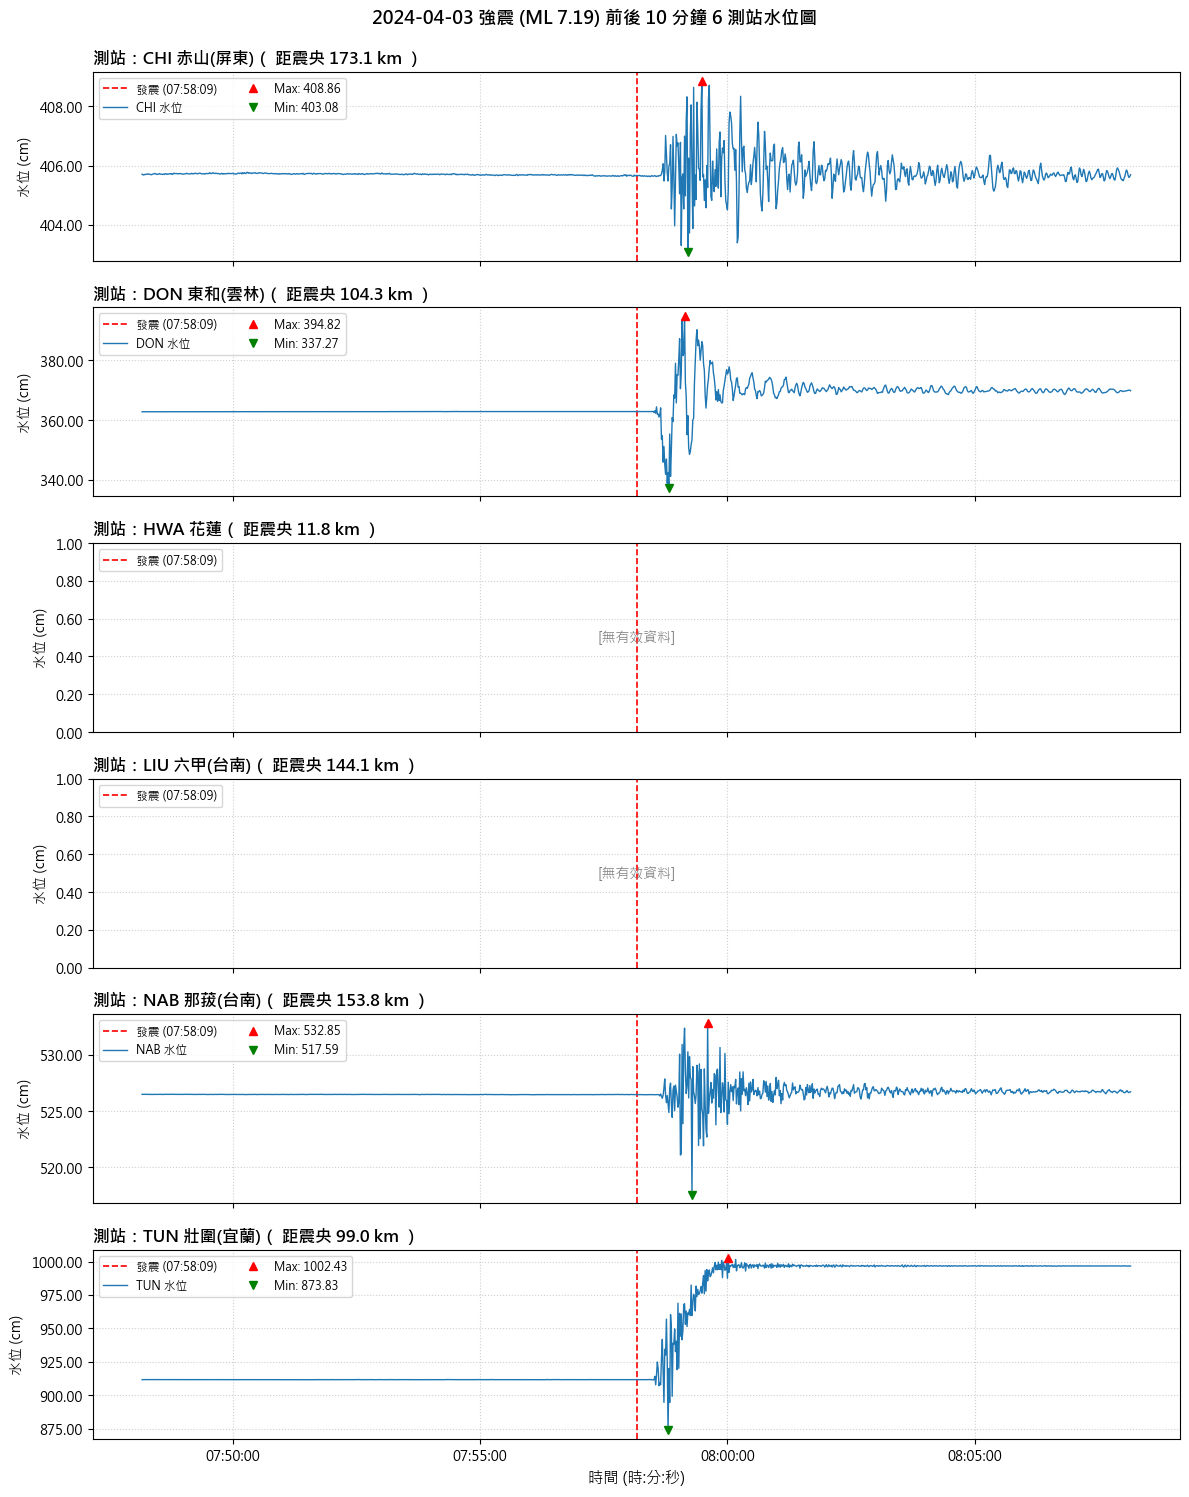


================ 📊 2024-04-03 強震 地下水位同震波幅統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (cm),最高 (cm),最低 (cm),最大全振幅 (cm),最大向上偏移,最大向下偏移
CHI,赤山(屏東),173.100000,405.690000,408.860000,403.080000,5.780000,3.170000,-2.610000
DON,東和(雲林),104.300000,362.840000,394.820000,337.270000,57.550000,31.980000,-25.570000
NAB,那菝(台南),153.800000,526.470000,532.850000,517.590000,15.260000,6.380000,-8.880000
TUN,壯圍(宜蘭),99.000000,911.620000,1002.430000,873.830000,128.600000,90.810000,-37.790000


In [30]:
# ======================================================================
# 📌 第一大地震：2024-04-03 花蓮強震 (ML 7.19, 07:58:09)
# ======================================================================

# 2024-04-03 前後 10 分鐘 6 測站地下水位變化與動態波幅統計
plot_seismic_event(rank=1, feature="water_level", mode="zoom", window_min=10, calc_stats=True)

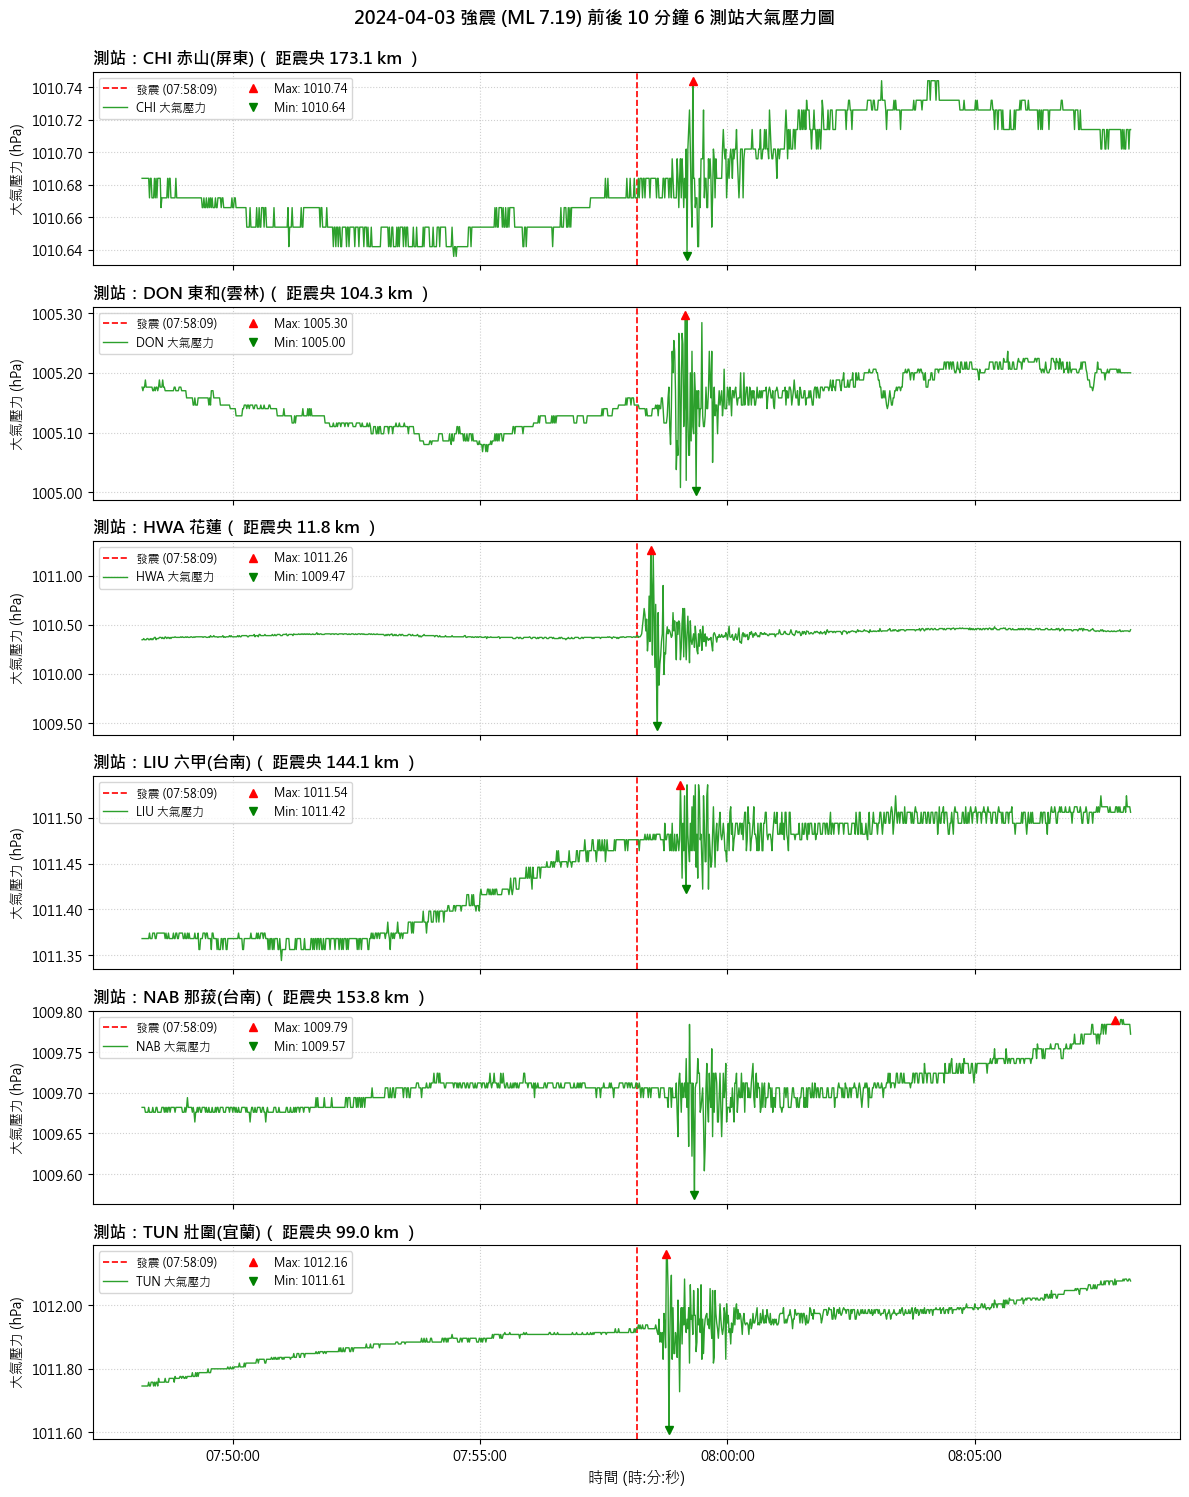


================ 📊 2024-04-03 強震 大氣壓力波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (hPa),最高 (hPa),最低 (hPa),最大全振幅 (hPa),最大向上偏移,最大向下偏移
CHI,赤山(屏東),173.100000,1010.660000,1010.740000,1010.640000,0.110000,0.090000,-0.020000
DON,東和(雲林),104.300000,1005.110000,1005.300000,1005.000000,0.290000,0.190000,-0.110000
HWA,花蓮,11.800000,1010.380000,1011.260000,1009.470000,1.790000,0.880000,-0.900000
LIU,六甲(台南),144.100000,1011.430000,1011.540000,1011.420000,0.110000,0.110000,-0.010000
NAB,那菝(台南),153.800000,1009.710000,1009.790000,1009.570000,0.220000,0.080000,-0.130000
TUN,壯圍(宜蘭),99.000000,1011.900000,1012.160000,1011.610000,0.550000,0.260000,-0.290000


In [31]:
# 2024-04-03 前後 10 分鐘 6 測站大氣壓力波動標示與統計
plot_seismic_event(rank=1, feature="pressure", mode="zoom", window_min=10, calc_stats=True)

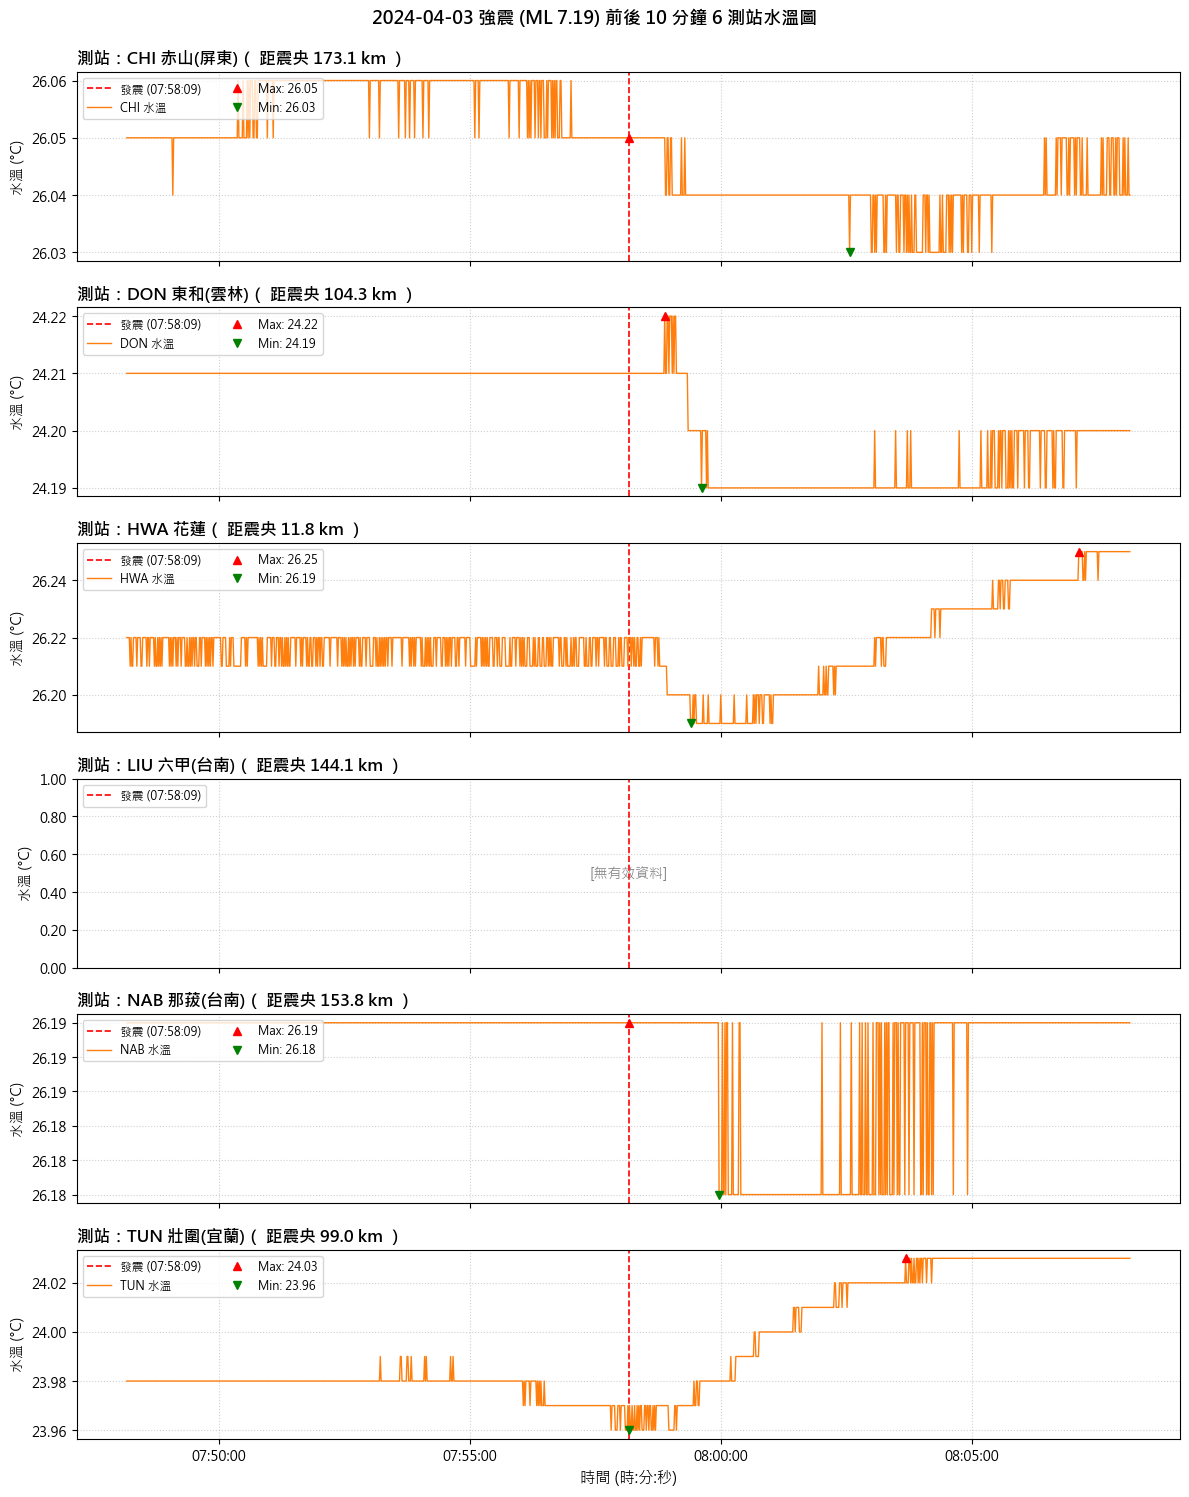


================ 📊 2024-04-03 強震 水溫波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (°C),最高 (°C),最低 (°C),最大全振幅 (°C),最大向上偏移,最大向下偏移
CHI,赤山(屏東),173.100000,26.060000,26.050000,26.030000,0.020000,-0.010000,-0.030000
DON,東和(雲林),104.300000,24.210000,24.220000,24.190000,0.030000,0.010000,-0.020000
HWA,花蓮,11.800000,26.220000,26.250000,26.190000,0.060000,0.030000,-0.030000
NAB,那菝(台南),153.800000,26.190000,26.190000,26.180000,0.010000,0.000000,-0.010000
TUN,壯圍(宜蘭),99.000000,23.980000,24.030000,23.960000,0.070000,0.050000,-0.020000


In [32]:
# 2024-04-03 前後 10 分鐘水溫變化圖(上水溫 (upper_temp))
plot_seismic_event(rank=1, feature="upper_temp", mode="zoom", window_min=10, calc_stats=True)

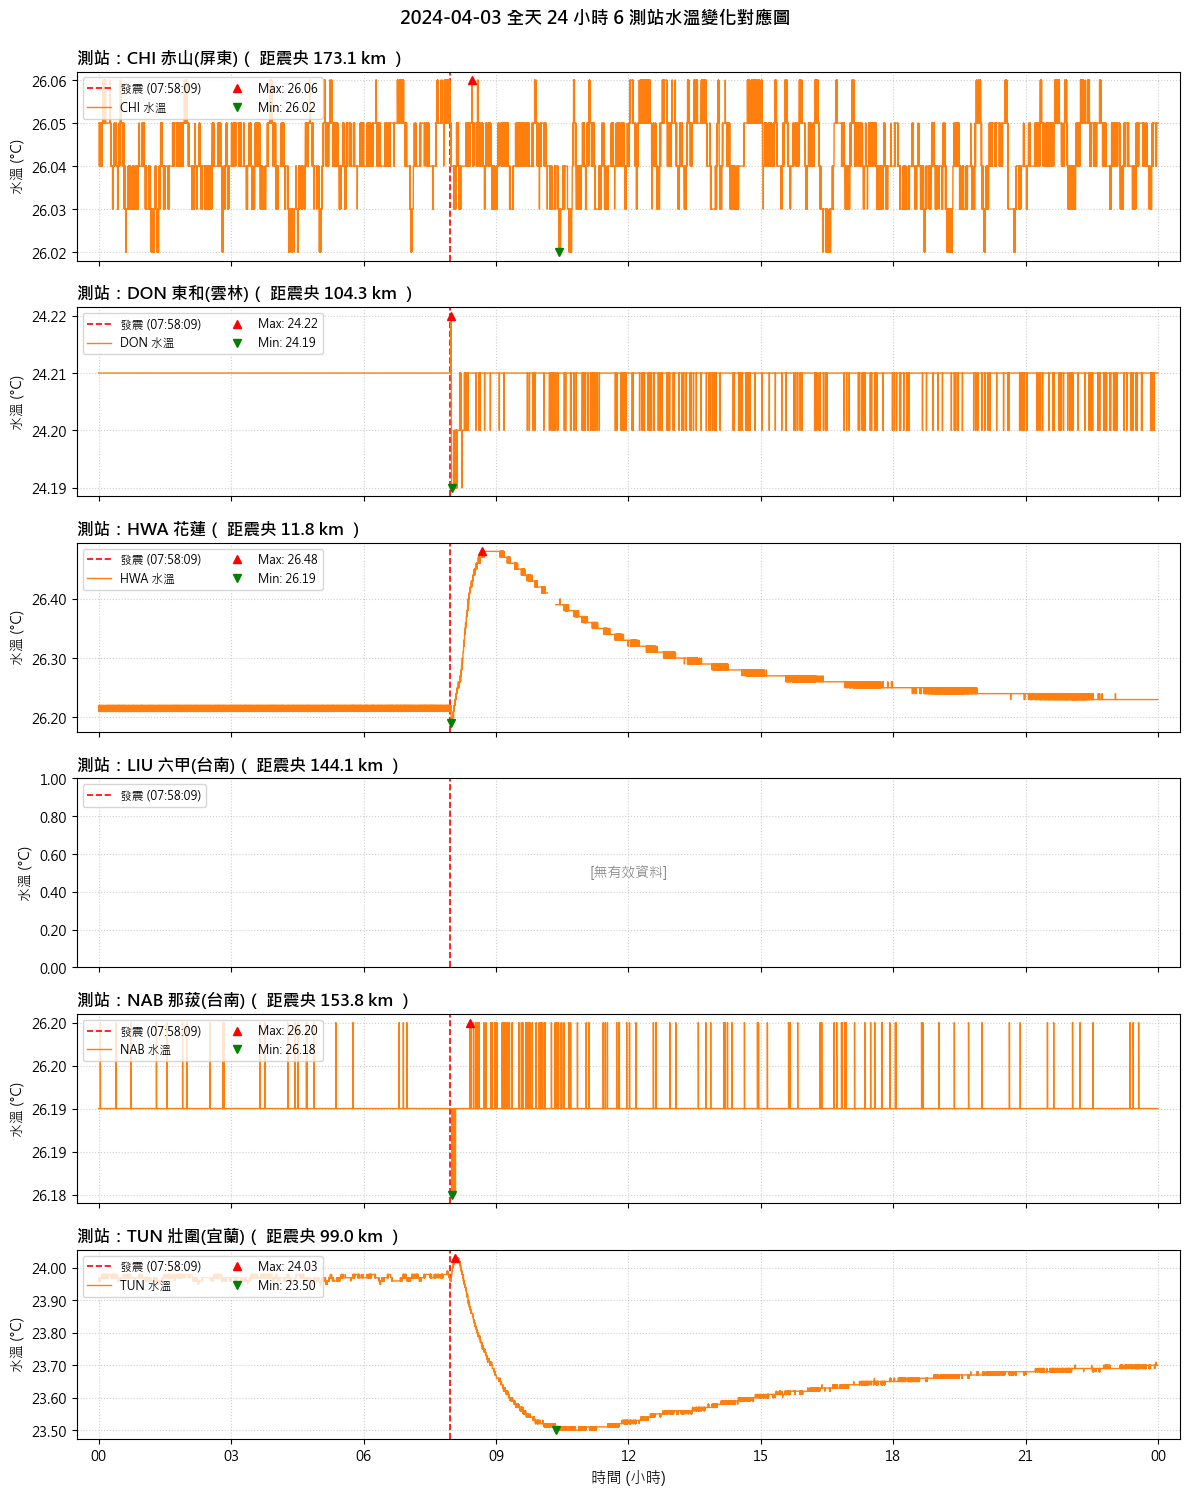


================ 📊 2024-04-03 強震 水溫波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (°C),最高 (°C),最低 (°C),最大全振幅 (°C),最大向上偏移,最大向下偏移
CHI,赤山(屏東),173.100000,26.060000,26.060000,26.020000,0.040000,0.000000,-0.040000
DON,東和(雲林),104.300000,24.210000,24.220000,24.190000,0.030000,0.010000,-0.020000
HWA,花蓮,11.800000,26.220000,26.480000,26.190000,0.290000,0.260000,-0.030000
NAB,那菝(台南),153.800000,26.190000,26.200000,26.180000,0.020000,0.010000,-0.010000
TUN,壯圍(宜蘭),99.000000,23.980000,24.030000,23.500000,0.530000,0.050000,-0.480000


In [33]:
# 2024-04-03 全天 24 小時 6 測站水溫變化圖(上水溫 (upper_temp))
plot_seismic_event(rank=1, feature="upper_temp", mode="day", calc_stats=True)

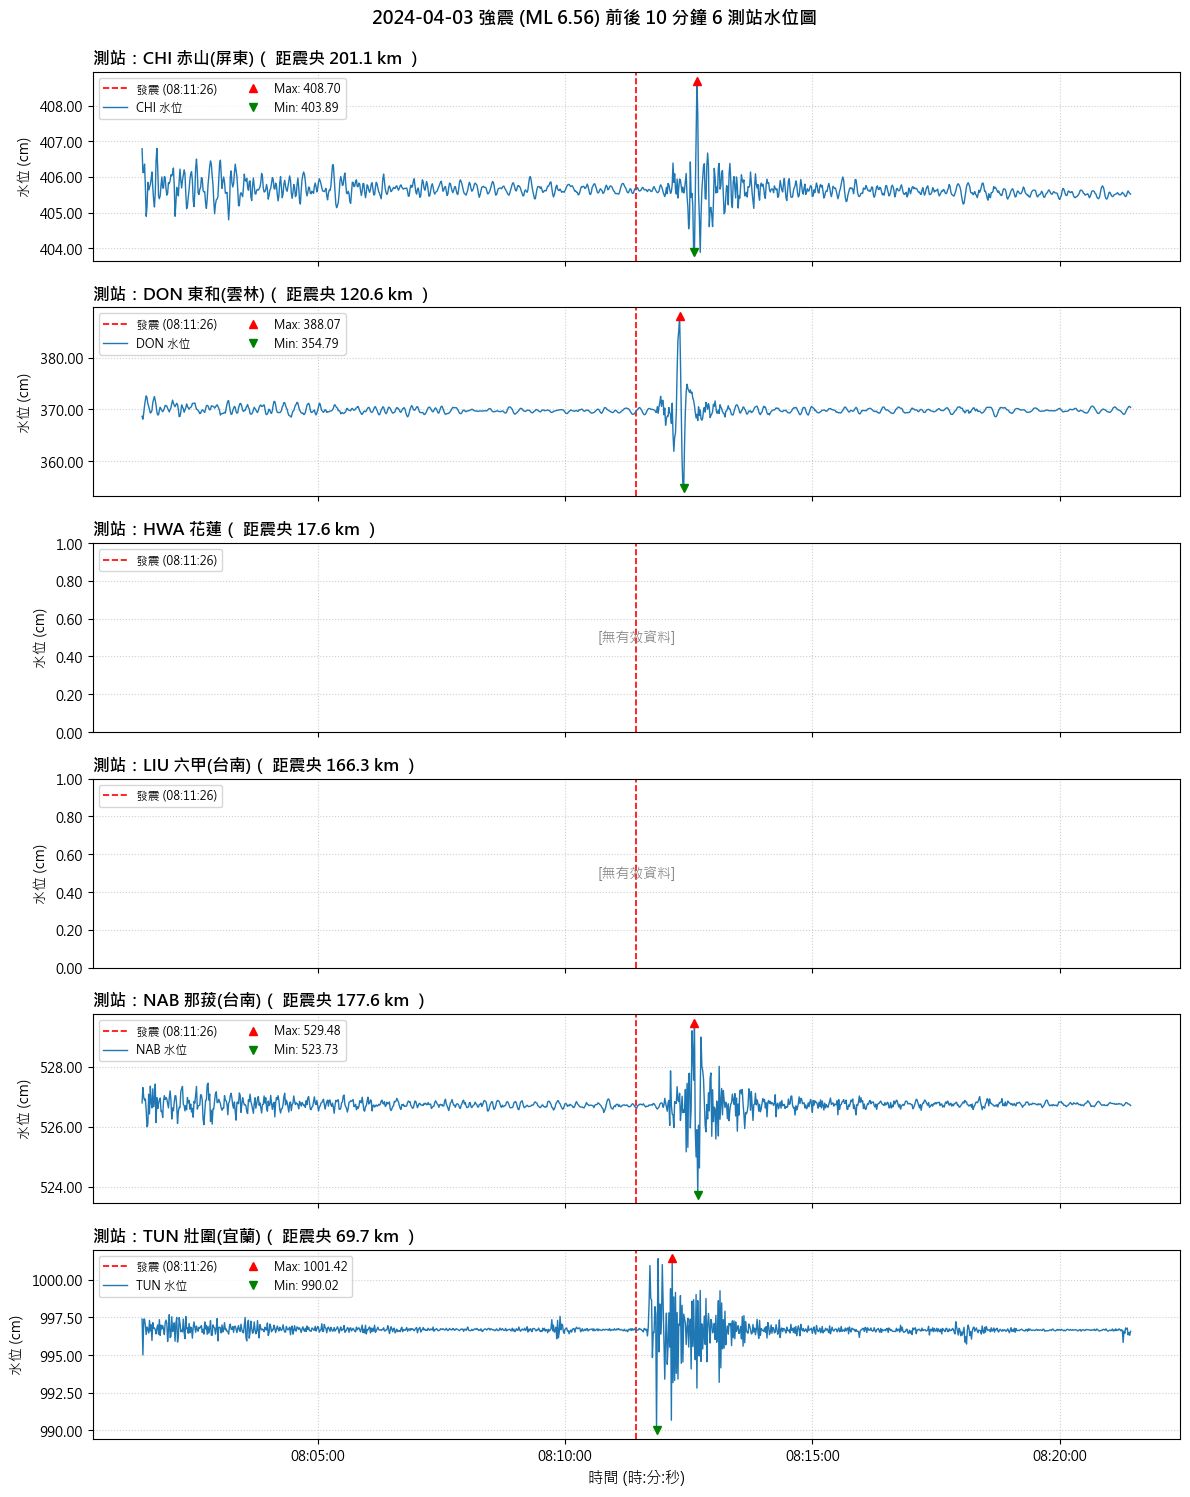


================ 📊 2024-04-03 強震 地下水位同震波幅統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (cm),最高 (cm),最低 (cm),最大全振幅 (cm),最大向上偏移,最大向下偏移
CHI,赤山(屏東),201.100000,405.670000,408.700000,403.890000,4.810000,3.030000,-1.780000
DON,東和(雲林),120.600000,369.730000,388.070000,354.790000,33.280000,18.340000,-14.940000
NAB,那菝(台南),177.600000,526.730000,529.480000,523.730000,5.750000,2.750000,-3.000000
TUN,壯圍(宜蘭),69.700000,996.690000,1001.420000,990.020000,11.400000,4.730000,-6.670000


In [35]:
# ======================================================================
# 📌 第七大地震：2024-04-03 花蓮強震 (ML 6.56, 08:11:26)
# ======================================================================

# 2024-04-03 前後 10 分鐘 6 測站地下水位變化與動態波幅統計
plot_seismic_event(rank=7, feature="water_level", mode="zoom", window_min=10, calc_stats=True)

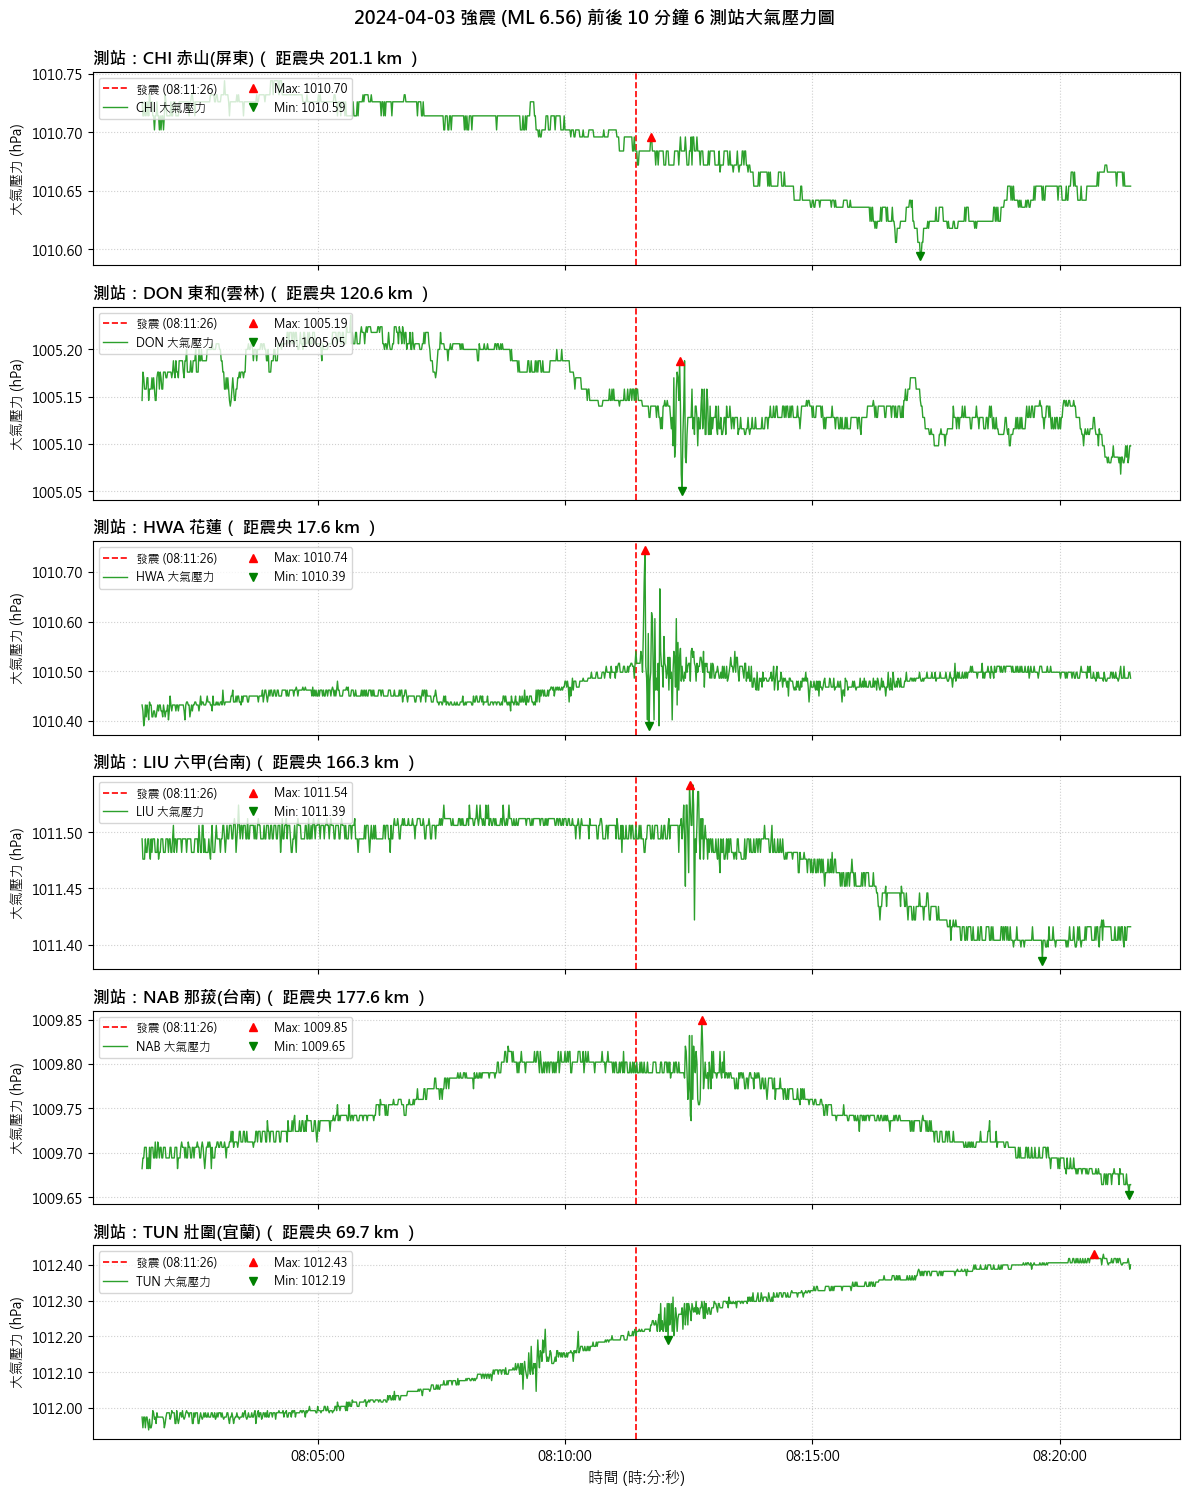


================ 📊 2024-04-03 強震 大氣壓力波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (hPa),最高 (hPa),最低 (hPa),最大全振幅 (hPa),最大向上偏移,最大向下偏移
CHI,赤山(屏東),201.100000,1010.710000,1010.700000,1010.590000,0.100000,-0.010000,-0.120000
DON,東和(雲林),120.600000,1005.180000,1005.190000,1005.050000,0.140000,0.000000,-0.130000
HWA,花蓮,17.600000,1010.460000,1010.740000,1010.390000,0.350000,0.290000,-0.070000
LIU,六甲(台南),166.300000,1011.510000,1011.540000,1011.390000,0.160000,0.030000,-0.120000
NAB,那菝(台南),177.600000,1009.790000,1009.850000,1009.650000,0.200000,0.060000,-0.140000
TUN,壯圍(宜蘭),69.700000,1012.110000,1012.430000,1012.190000,0.240000,0.320000,0.080000


In [37]:
# 2024-04-03 前後 10 分鐘 6 測站大氣壓力波動標示與統計
plot_seismic_event(rank=7, feature="pressure", mode="zoom", window_min=10, calc_stats=True)

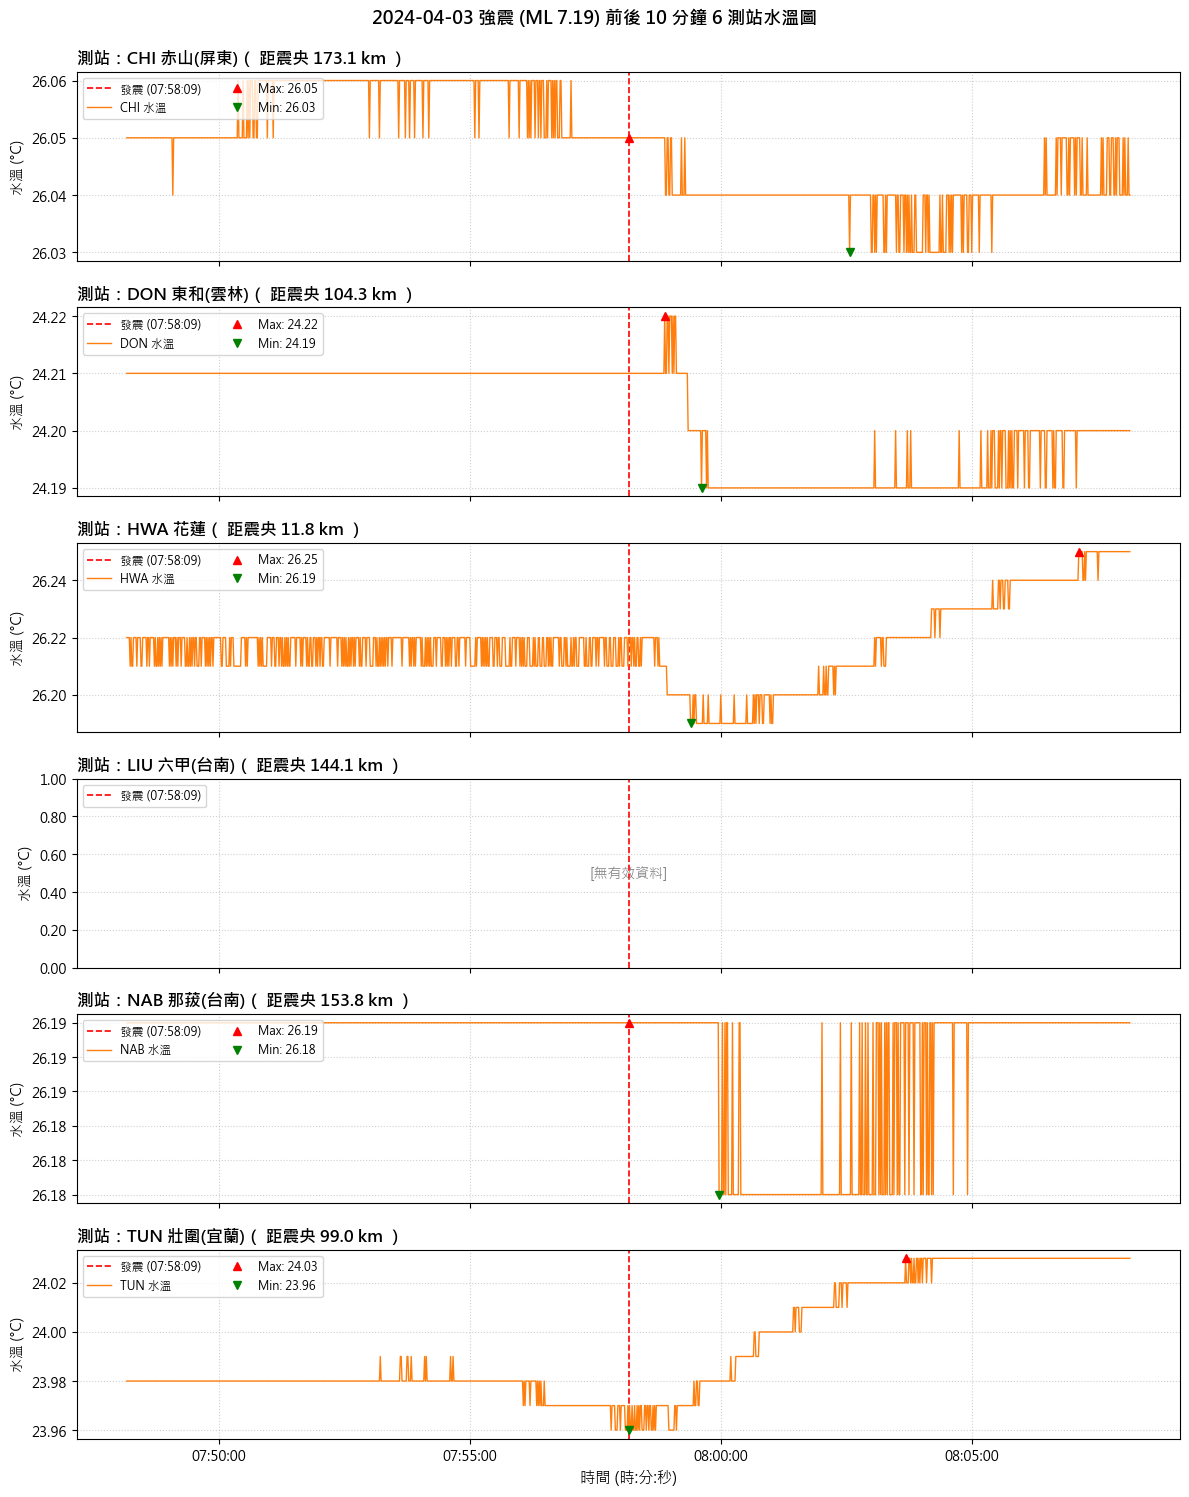


================ 📊 2024-04-03 強震 水溫波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (°C),最高 (°C),最低 (°C),最大全振幅 (°C),最大向上偏移,最大向下偏移
CHI,赤山(屏東),173.100000,26.060000,26.050000,26.030000,0.020000,-0.010000,-0.030000
DON,東和(雲林),104.300000,24.210000,24.220000,24.190000,0.030000,0.010000,-0.020000
HWA,花蓮,11.800000,26.220000,26.250000,26.190000,0.060000,0.030000,-0.030000
NAB,那菝(台南),153.800000,26.190000,26.190000,26.180000,0.010000,0.000000,-0.010000
TUN,壯圍(宜蘭),99.000000,23.980000,24.030000,23.960000,0.070000,0.050000,-0.020000


In [39]:
# 2024-04-03 前後 10 分鐘水溫變化圖(上水溫 (upper_temp))
plot_seismic_event(rank=1, feature="upper_temp", mode="zoom", window_min=10, calc_stats=True)

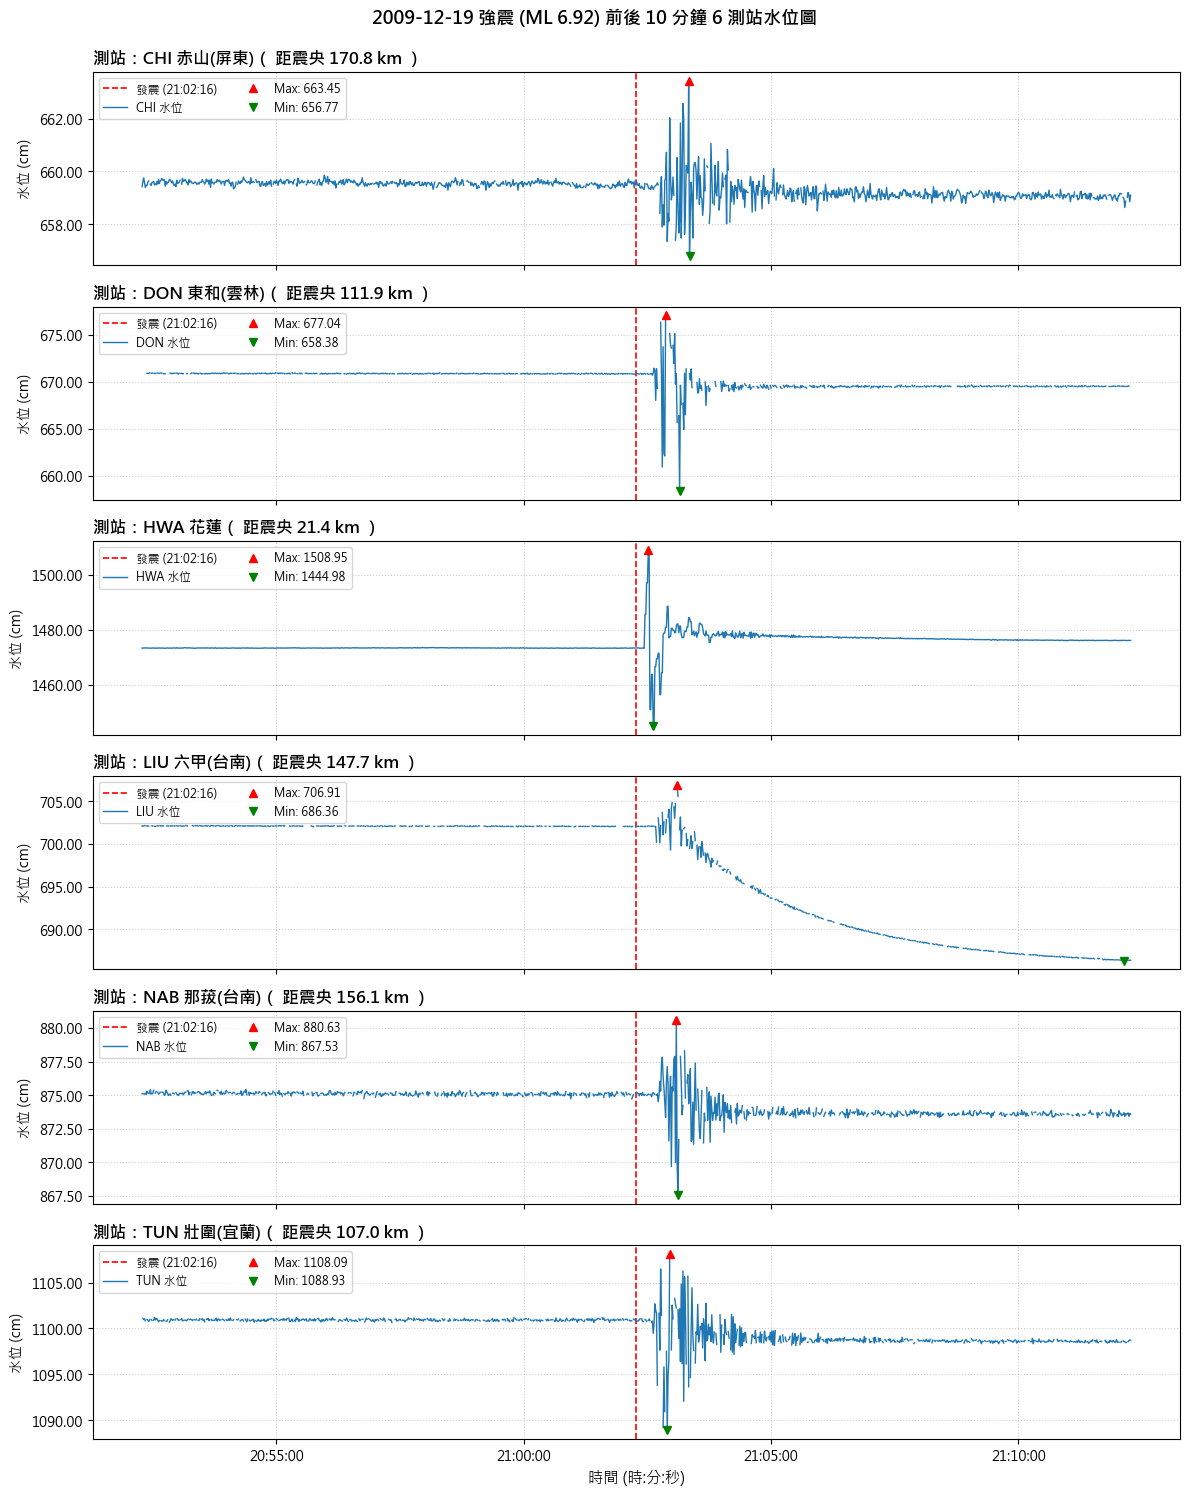


================ 📊 2009-12-19 強震 地下水位同震波幅統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (cm),最高 (cm),最低 (cm),最大全振幅 (cm),最大向上偏移,最大向下偏移
CHI,赤山(屏東),170.800000,659.530000,663.450000,656.770000,6.680000,3.920000,-2.760000
DON,東和(雲林),111.900000,670.850000,677.040000,658.380000,18.660000,6.190000,-12.470000
HWA,花蓮,21.400000,1473.320000,1508.950000,1444.980000,63.970000,35.630000,-28.340000
LIU,六甲(台南),147.700000,702.060000,706.910000,686.360000,20.550000,4.850000,-15.700000
NAB,那菝(台南),156.100000,875.060000,880.630000,867.530000,13.100000,5.570000,-7.530000
TUN,壯圍(宜蘭),107.000000,1100.920000,1108.090000,1088.930000,19.160000,7.170000,-11.990000


In [34]:
# ======================================================================
# 📌 第二大地震：2009-12-19 花蓮外海地震 (ML 6.92, 21:02:16)
# ======================================================================

# 2009-12-19 前後 10 分鐘 6 測站地下水位變化與動態波幅統計
plot_seismic_event(rank=2, feature="water_level", mode="zoom", window_min=10, calc_stats=True)

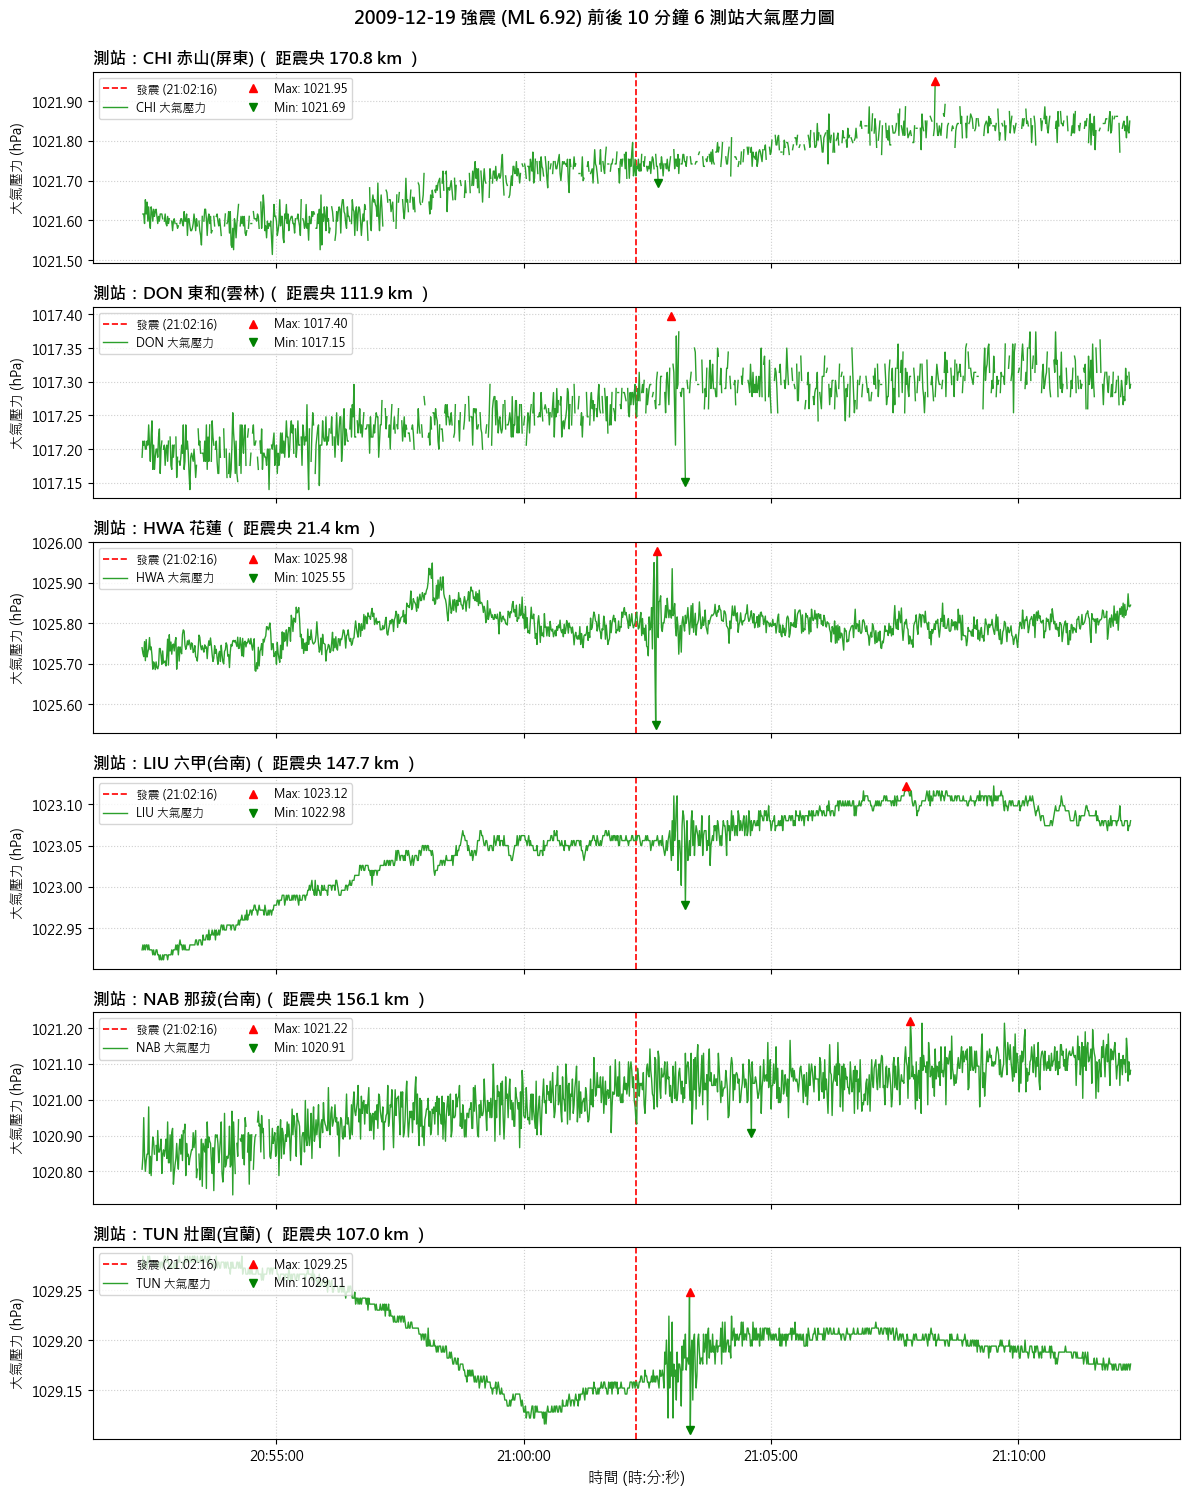


================ 📊 2009-12-19 強震 大氣壓力波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (hPa),最高 (hPa),最低 (hPa),最大全振幅 (hPa),最大向上偏移,最大向下偏移
CHI,赤山(屏東),170.800000,1021.710000,1021.950000,1021.690000,0.260000,0.240000,-0.010000
DON,東和(雲林),111.900000,1017.250000,1017.400000,1017.150000,0.250000,0.150000,-0.100000
HWA,花蓮,21.400000,1025.820000,1025.980000,1025.550000,0.430000,0.160000,-0.270000
LIU,六甲(台南),147.700000,1023.050000,1023.120000,1022.980000,0.140000,0.070000,-0.070000
NAB,那菝(台南),156.100000,1020.990000,1021.220000,1020.910000,0.310000,0.230000,-0.080000
TUN,壯圍(宜蘭),107.000000,1029.160000,1029.250000,1029.110000,0.140000,0.090000,-0.050000


In [35]:
# 2009-12-19 前後 10 分鐘 6 測站大氣壓力波動標示與統計
plot_seismic_event(rank=2, feature="pressure", mode="zoom", window_min=10, calc_stats=True)

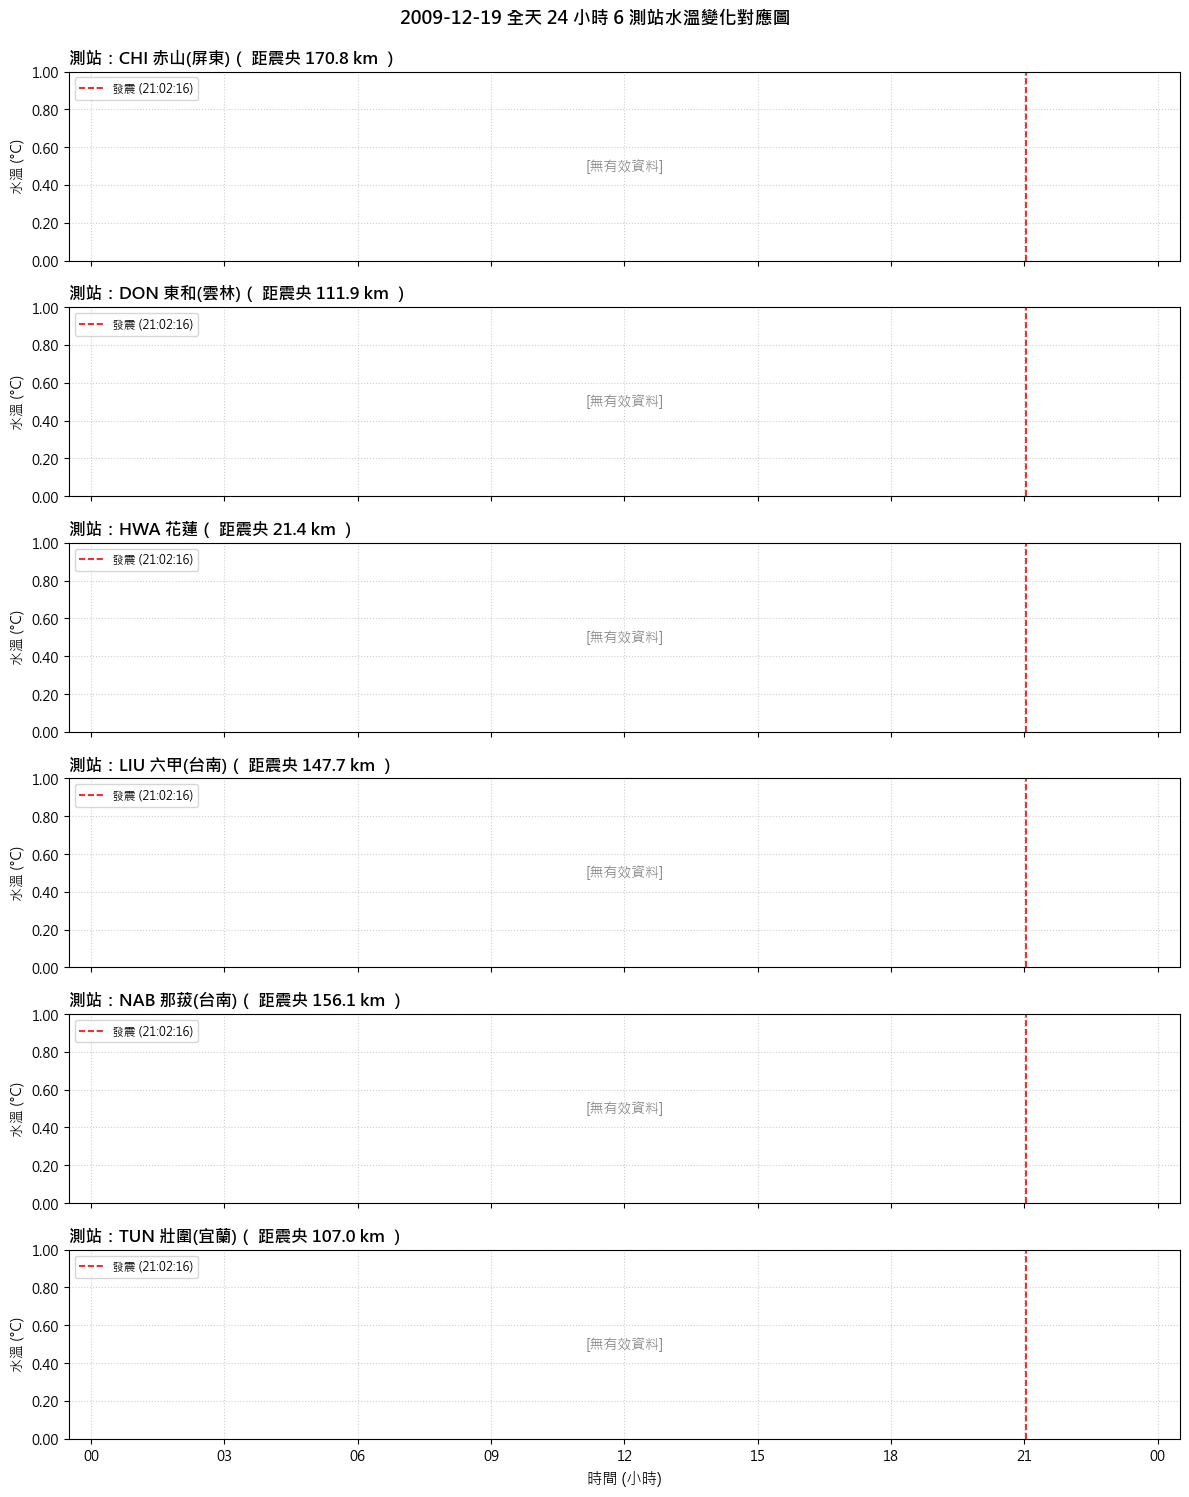

In [36]:
# 2009-12-19 全天 24 小時 6 測站水溫變化圖(上水溫 (upper_temp))
plot_seismic_event(rank=2, feature="upper_temp", mode="day", calc_stats=True)

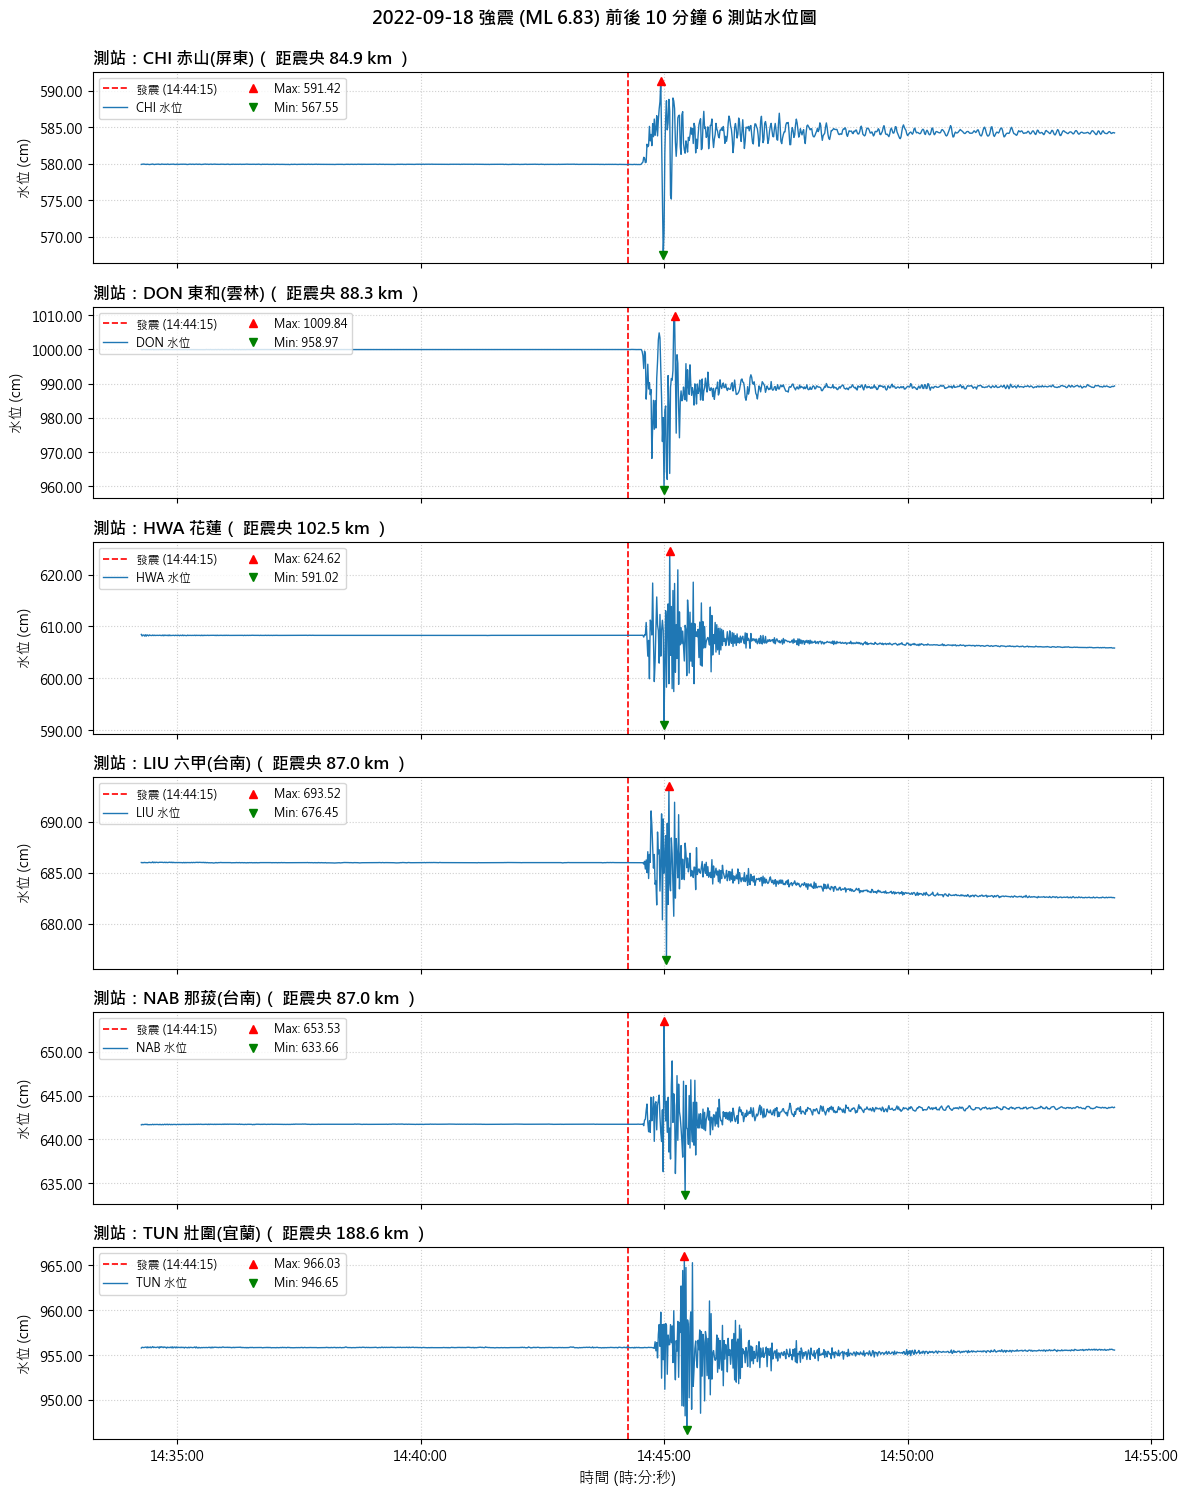


================ 📊 2022-09-18 強震 地下水位同震波幅統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (cm),最高 (cm),最低 (cm),最大全振幅 (cm),最大向上偏移,最大向下偏移
CHI,赤山(屏東),84.900000,579.940000,591.420000,567.550000,23.870000,11.480000,-12.390000
DON,東和(雲林),88.300000,999.950000,1009.840000,958.970000,50.870000,9.890000,-40.980000
HWA,花蓮,102.500000,608.290000,624.620000,591.020000,33.600000,16.330000,-17.270000
LIU,六甲(台南),87.000000,685.990000,693.520000,676.450000,17.070000,7.530000,-9.540000
NAB,那菝(台南),87.000000,641.730000,653.530000,633.660000,19.870000,11.800000,-8.070000
TUN,壯圍(宜蘭),188.600000,955.830000,966.030000,946.650000,19.380000,10.200000,-9.180000


In [37]:
# ======================================================================
# 📌 第三大地震：2022-09-18 台東池上地震 (ML 6.83, 14:44:15)
# ======================================================================

# 2022-09-18 前後 10 分鐘 6 測站地下水位變化與動態波幅統計
plot_seismic_event(rank=3, feature="water_level", mode="zoom", window_min=10, calc_stats=True)

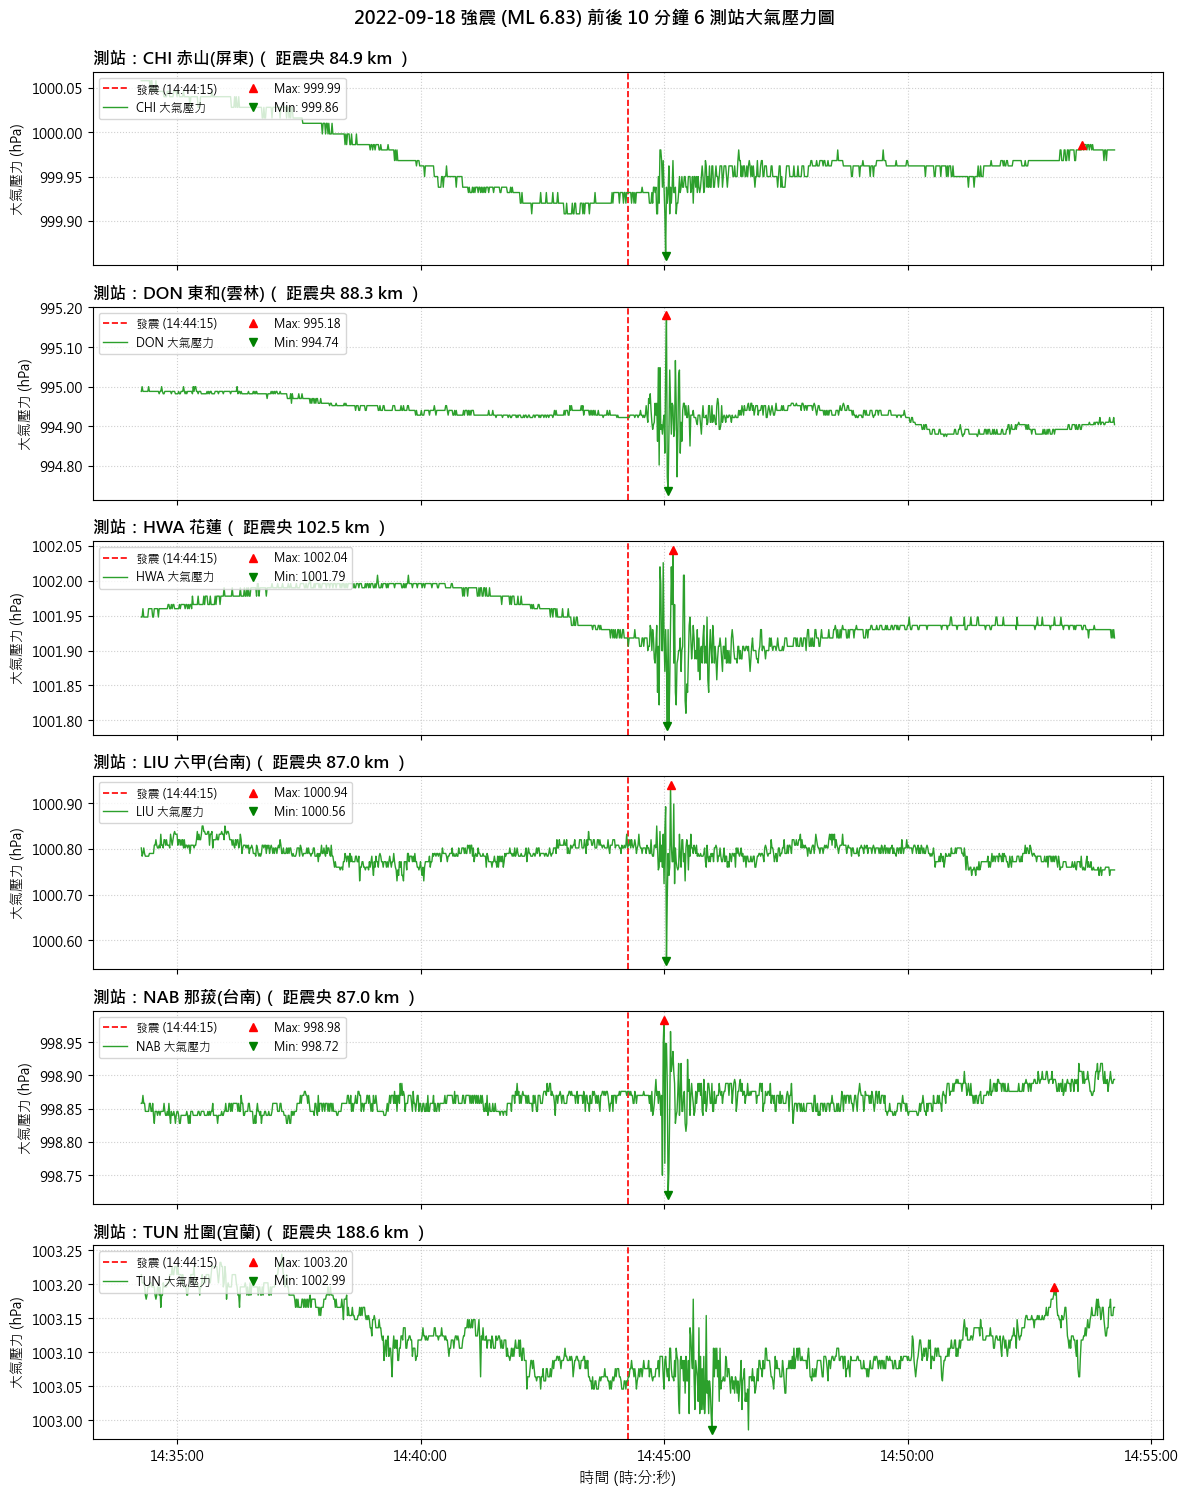


================ 📊 2022-09-18 強震 大氣壓力波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (hPa),最高 (hPa),最低 (hPa),最大全振幅 (hPa),最大向上偏移,最大向下偏移
CHI,赤山(屏東),84.900000,999.940000,999.990000,999.860000,0.130000,0.050000,-0.080000
DON,東和(雲林),88.300000,994.930000,995.180000,994.740000,0.440000,0.250000,-0.200000
HWA,花蓮,102.500000,1001.970000,1002.040000,1001.790000,0.250000,0.080000,-0.180000
LIU,六甲(台南),87.000000,1000.790000,1000.940000,1000.560000,0.380000,0.150000,-0.230000
NAB,那菝(台南),87.000000,998.860000,998.980000,998.720000,0.260000,0.120000,-0.140000
TUN,壯圍(宜蘭),188.600000,1003.100000,1003.200000,1002.990000,0.210000,0.100000,-0.110000


In [38]:
# 2022-09-18 前後 10 分鐘 6 測站大氣壓力波動標示與統計
plot_seismic_event(rank=3, feature="pressure", mode="zoom", window_min=10, calc_stats=True)

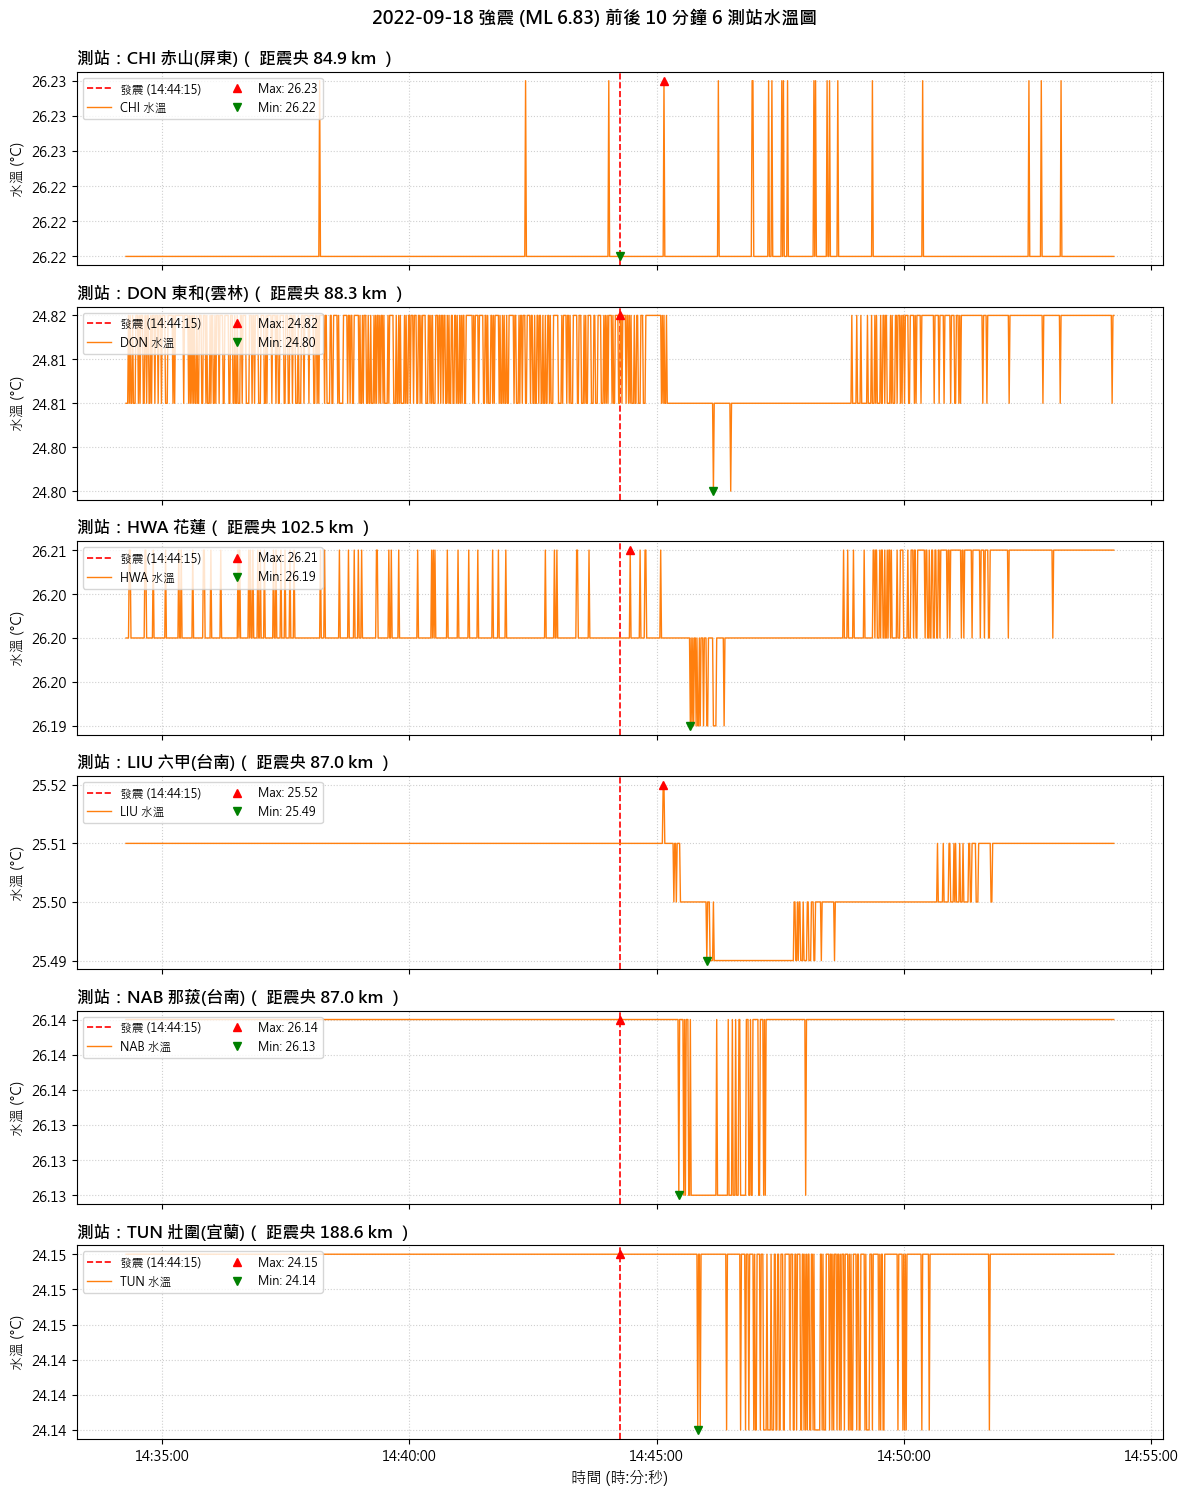


================ 📊 2022-09-18 強震 水溫波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (°C),最高 (°C),最低 (°C),最大全振幅 (°C),最大向上偏移,最大向下偏移
CHI,赤山(屏東),84.900000,26.220000,26.230000,26.220000,0.010000,0.010000,-0.000000
DON,東和(雲林),88.300000,24.820000,24.820000,24.800000,0.020000,0.000000,-0.020000
HWA,花蓮,102.500000,26.200000,26.210000,26.190000,0.020000,0.010000,-0.010000
LIU,六甲(台南),87.000000,25.510000,25.520000,25.490000,0.030000,0.010000,-0.020000
NAB,那菝(台南),87.000000,26.140000,26.140000,26.130000,0.010000,0.000000,-0.010000
TUN,壯圍(宜蘭),188.600000,24.150000,24.150000,24.140000,0.010000,-0.000000,-0.010000


In [39]:
# 2022-09-18 前後 10 分鐘水溫變化圖(上水溫 (upper_temp))
plot_seismic_event(rank=3, feature="upper_temp", mode="zoom", window_min=10, calc_stats=True)

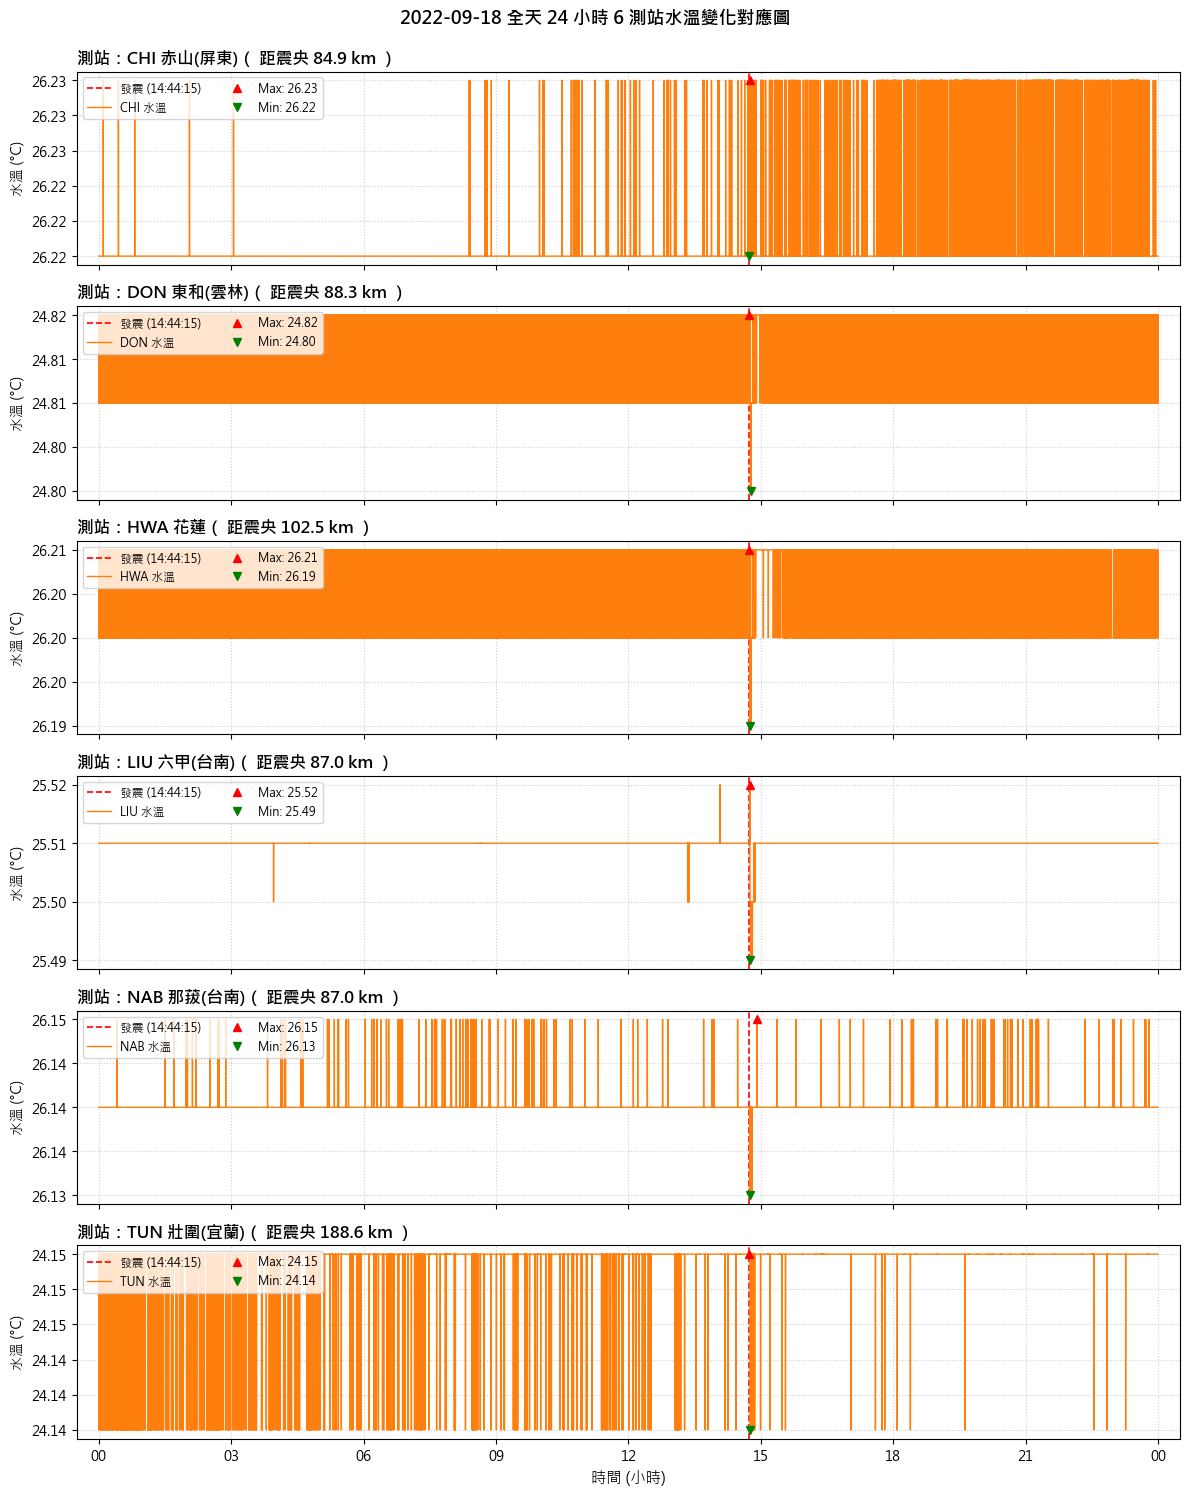


================ 📊 2022-09-18 強震 水溫波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (°C),最高 (°C),最低 (°C),最大全振幅 (°C),最大向上偏移,最大向下偏移
CHI,赤山(屏東),84.900000,26.220000,26.230000,26.220000,0.010000,0.010000,-0.000000
DON,東和(雲林),88.300000,24.820000,24.820000,24.800000,0.020000,0.000000,-0.020000
HWA,花蓮,102.500000,26.200000,26.210000,26.190000,0.020000,0.010000,-0.010000
LIU,六甲(台南),87.000000,25.510000,25.520000,25.490000,0.030000,0.010000,-0.020000
NAB,那菝(台南),87.000000,26.140000,26.150000,26.130000,0.020000,0.010000,-0.010000
TUN,壯圍(宜蘭),188.600000,24.150000,24.150000,24.140000,0.010000,-0.000000,-0.010000


In [40]:
# 2022-09-18 全天 24 小時 6 測站水溫變化圖(上水溫 (upper_temp))
plot_seismic_event(rank=3, feature="upper_temp", mode="day", calc_stats=True)

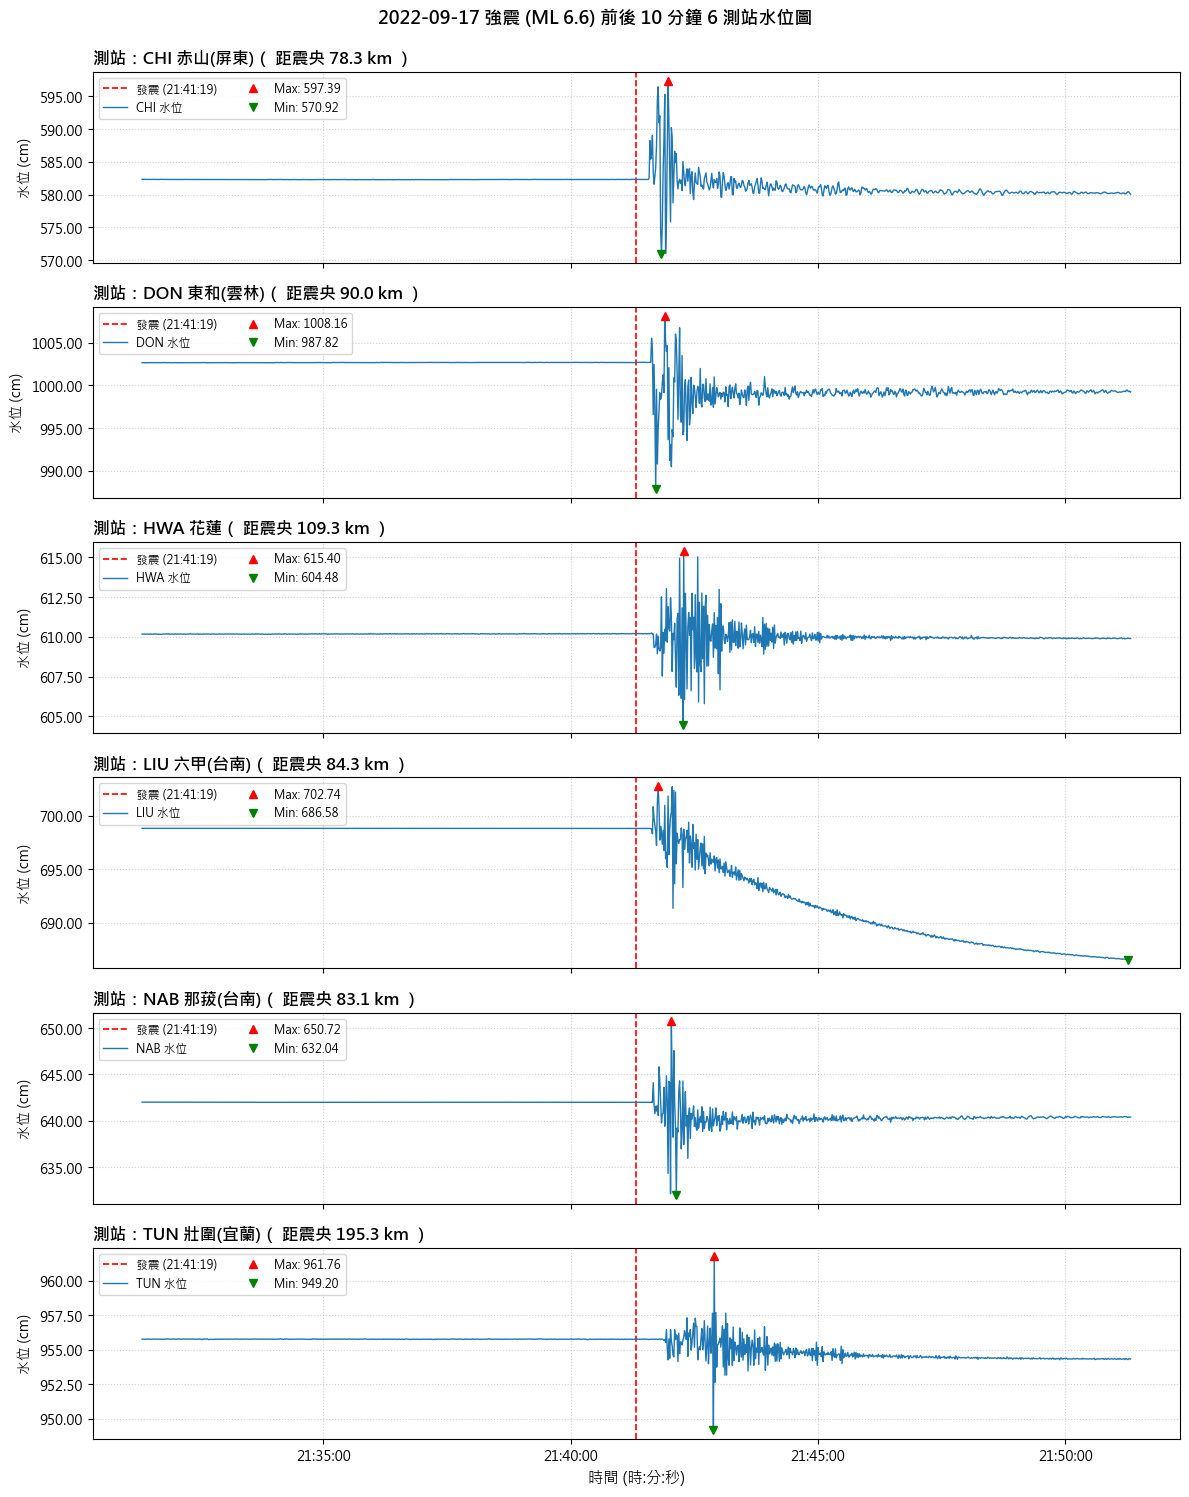


================ 📊 2022-09-17 強震 地下水位同震波幅統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (cm),最高 (cm),最低 (cm),最大全振幅 (cm),最大向上偏移,最大向下偏移
CHI,赤山(屏東),78.300000,582.300000,597.390000,570.920000,26.470000,15.090000,-11.380000
DON,東和(雲林),90.000000,1002.690000,1008.160000,987.820000,20.340000,5.470000,-14.870000
HWA,花蓮,109.300000,610.190000,615.400000,604.480000,10.920000,5.210000,-5.710000
LIU,六甲(台南),84.300000,698.810000,702.740000,686.580000,16.160000,3.930000,-12.230000
NAB,那菝(台南),83.100000,642.010000,650.720000,632.040000,18.680000,8.710000,-9.970000
TUN,壯圍(宜蘭),195.300000,955.770000,961.760000,949.200000,12.560000,5.990000,-6.570000


In [22]:
# ======================================================================
# 📌 第五大地震：2022-09-17 台東關山地震 (ML 6.60, 21:41:19)
# ======================================================================

# 2022-09-17 前後 10 分鐘 6 測站地下水位變化與動態波幅統計
plot_seismic_event(rank=5, feature="water_level", mode="zoom", window_min=10, calc_stats=True)

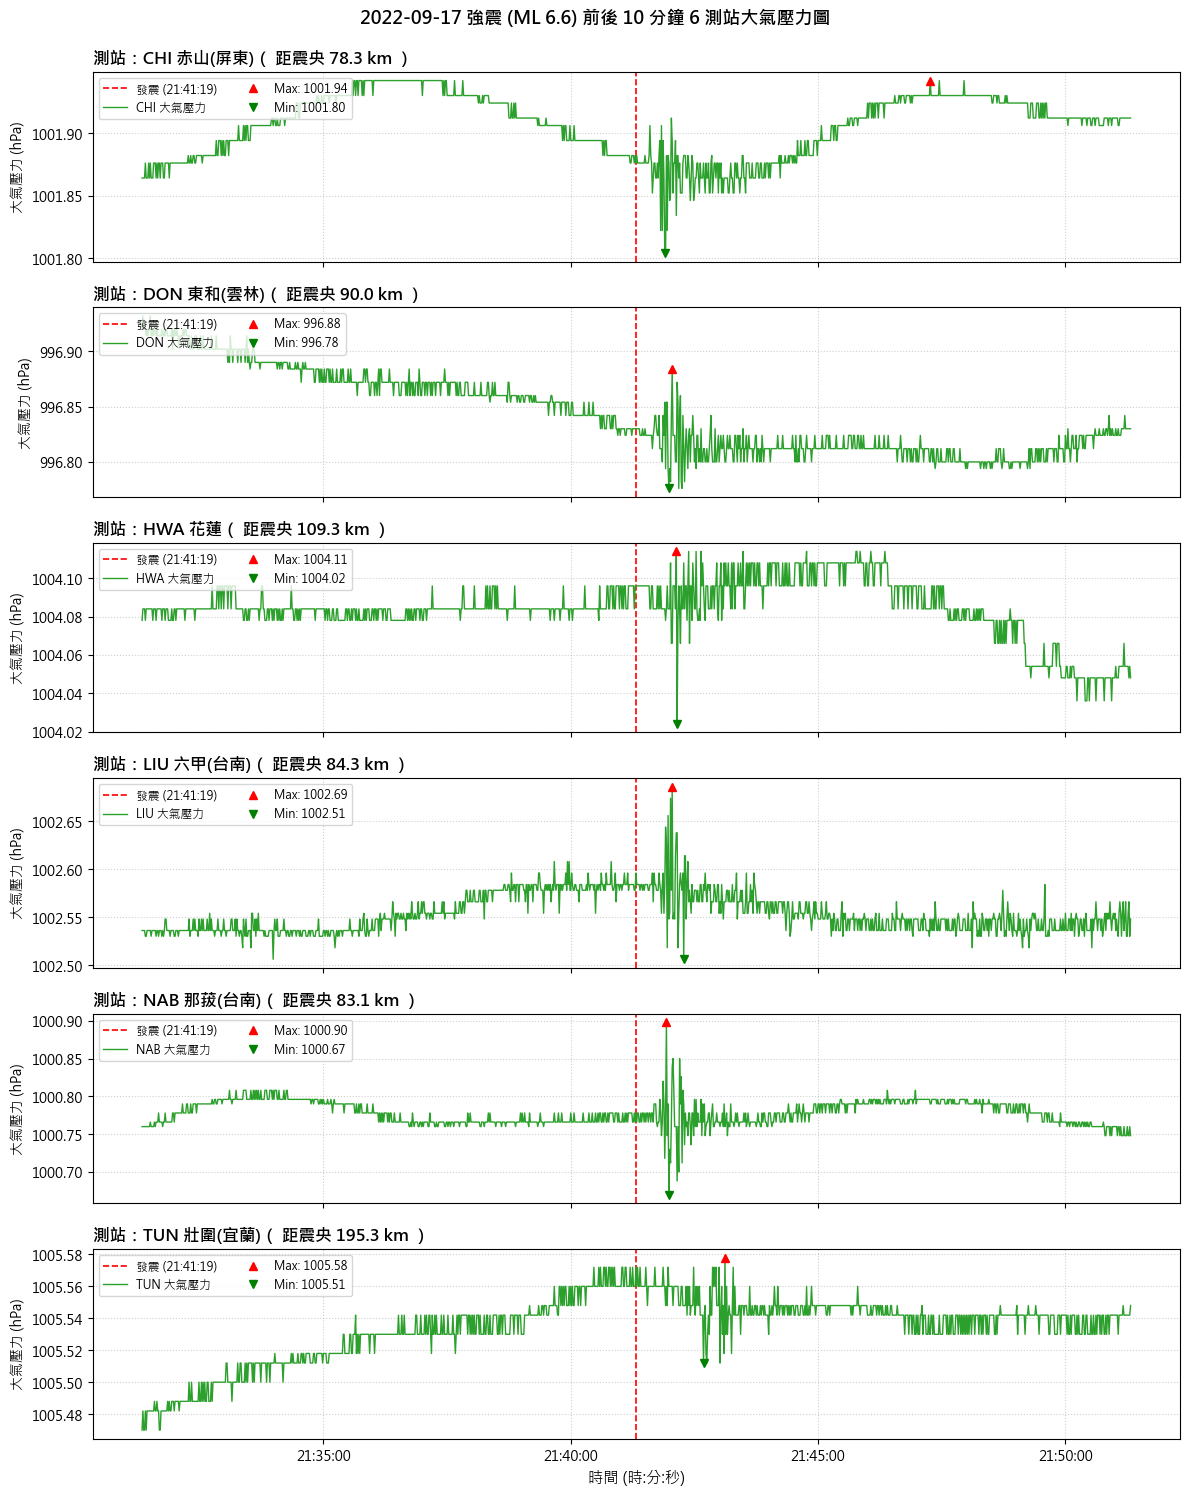


================ 📊 2022-09-17 強震 大氣壓力波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (hPa),最高 (hPa),最低 (hPa),最大全振幅 (hPa),最大向上偏移,最大向下偏移
CHI,赤山(屏東),78.300000,1001.920000,1001.940000,1001.800000,0.140000,0.030000,-0.110000
DON,東和(雲林),90.000000,996.860000,996.880000,996.780000,0.110000,0.030000,-0.080000
HWA,花蓮,109.300000,1004.080000,1004.110000,1004.020000,0.090000,0.030000,-0.060000
LIU,六甲(台南),84.300000,1002.570000,1002.690000,1002.510000,0.180000,0.110000,-0.070000
NAB,那菝(台南),83.100000,1000.770000,1000.900000,1000.670000,0.230000,0.130000,-0.100000
TUN,壯圍(宜蘭),195.300000,1005.540000,1005.580000,1005.510000,0.070000,0.030000,-0.030000


In [24]:
# 2022-09-17 前後 10 分鐘 6 測站大氣壓力波動標示與統計
plot_seismic_event(rank=5, feature="pressure", mode="zoom", window_min=10, calc_stats=True)

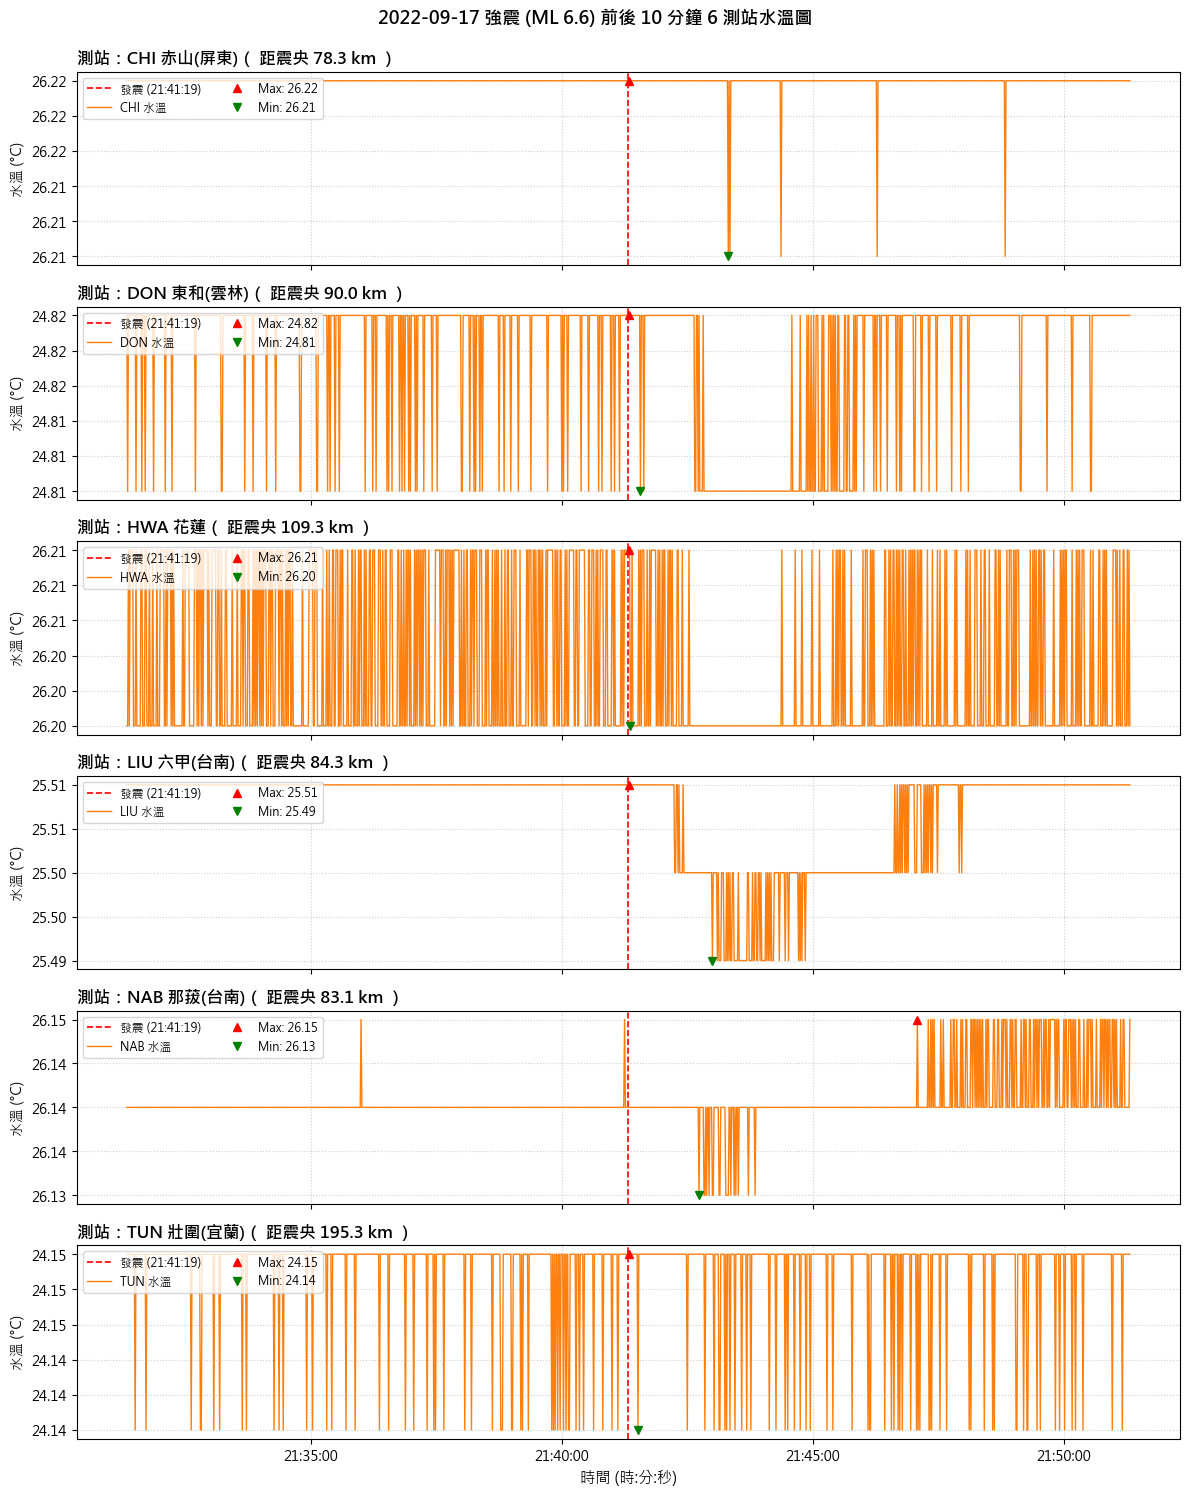


================ 📊 2022-09-17 強震 水溫波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (°C),最高 (°C),最低 (°C),最大全振幅 (°C),最大向上偏移,最大向下偏移
CHI,赤山(屏東),78.300000,26.220000,26.220000,26.210000,0.010000,0.000000,-0.010000
DON,東和(雲林),90.000000,24.820000,24.820000,24.810000,0.010000,0.000000,-0.010000
HWA,花蓮,109.300000,26.200000,26.210000,26.200000,0.010000,0.010000,-0.000000
LIU,六甲(台南),84.300000,25.510000,25.510000,25.490000,0.020000,0.000000,-0.020000
NAB,那菝(台南),83.100000,26.140000,26.150000,26.130000,0.020000,0.010000,-0.010000
TUN,壯圍(宜蘭),195.300000,24.150000,24.150000,24.140000,0.010000,0.000000,-0.010000


In [28]:
# 2022-09-17 前後 10 分鐘水溫變化圖(上水溫 (upper_temp))
plot_seismic_event(rank=5, feature="upper_temp", mode="zoom", window_min=10, calc_stats=True)

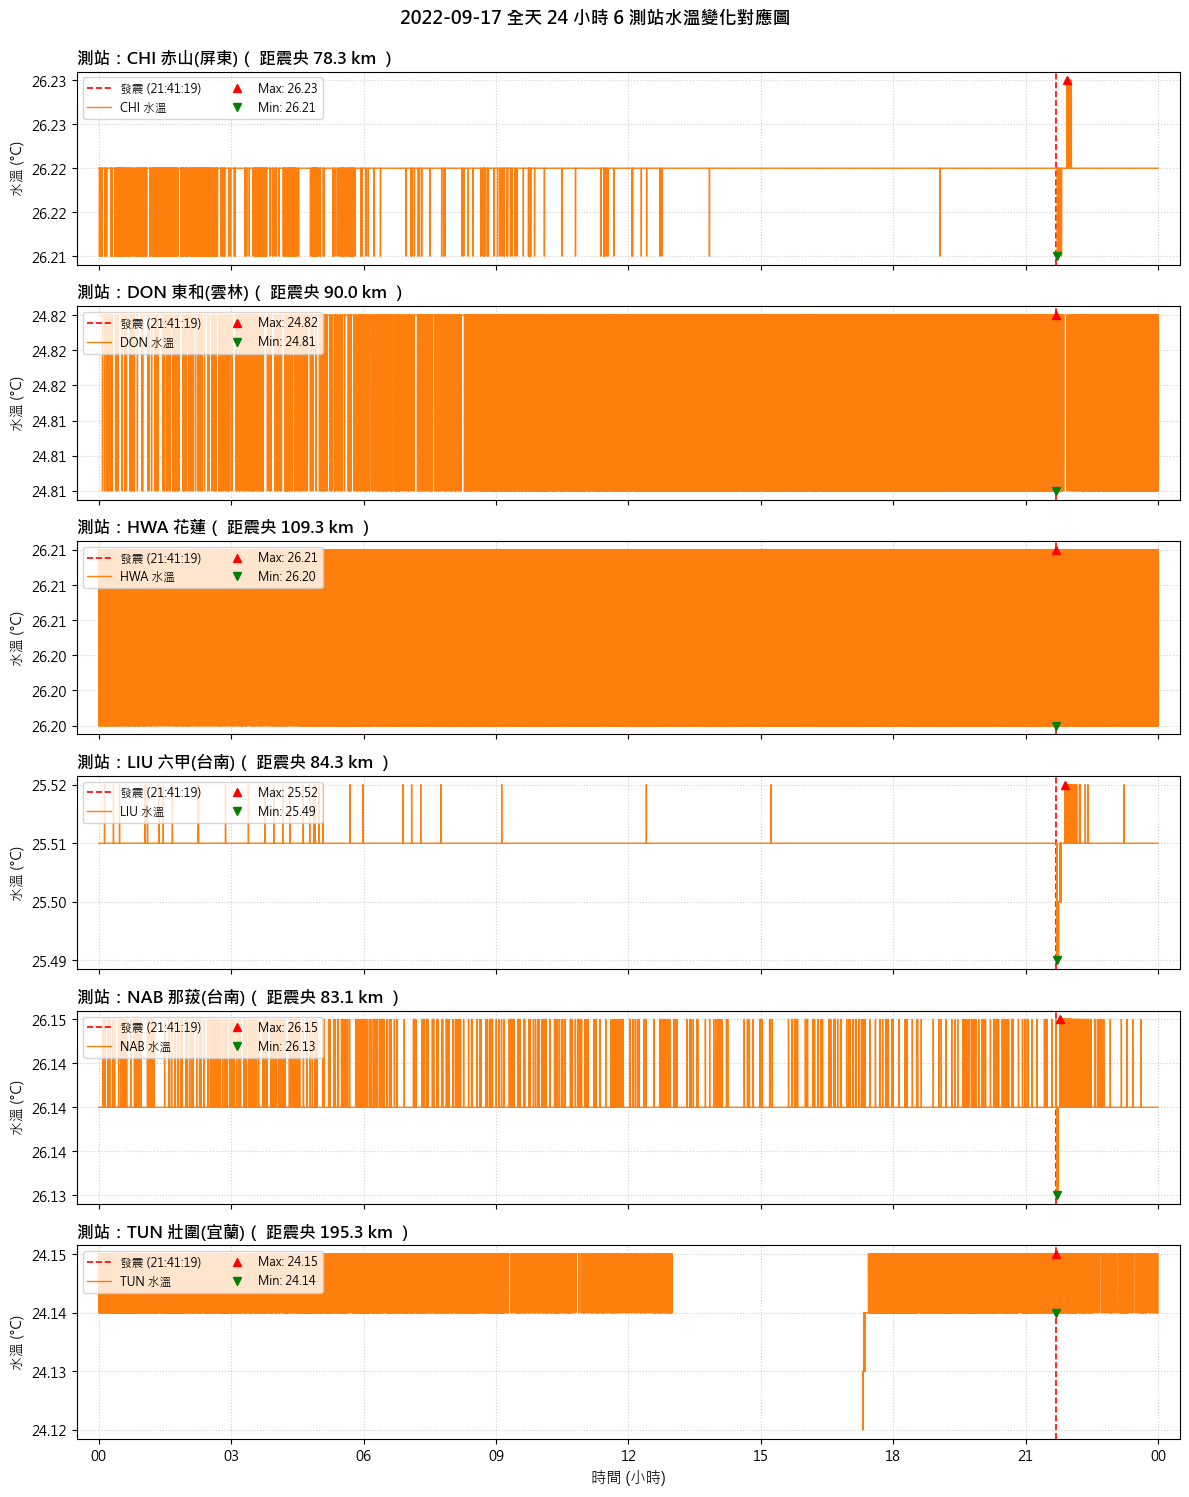


================ 📊 2022-09-17 強震 水溫波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (°C),最高 (°C),最低 (°C),最大全振幅 (°C),最大向上偏移,最大向下偏移
CHI,赤山(屏東),78.300000,26.220000,26.230000,26.210000,0.020000,0.010000,-0.010000
DON,東和(雲林),90.000000,24.820000,24.820000,24.810000,0.010000,0.000000,-0.010000
HWA,花蓮,109.300000,26.200000,26.210000,26.200000,0.010000,0.010000,-0.000000
LIU,六甲(台南),84.300000,25.510000,25.520000,25.490000,0.030000,0.010000,-0.020000
NAB,那菝(台南),83.100000,26.140000,26.150000,26.130000,0.020000,0.010000,-0.010000
TUN,壯圍(宜蘭),195.300000,24.150000,24.150000,24.140000,0.010000,0.000000,-0.010000


In [30]:
# 2022-09-17 全天 24 小時 6 測站水溫變化圖(上水溫 (upper_temp))
plot_seismic_event(rank=5, feature="upper_temp", mode="day", calc_stats=True)

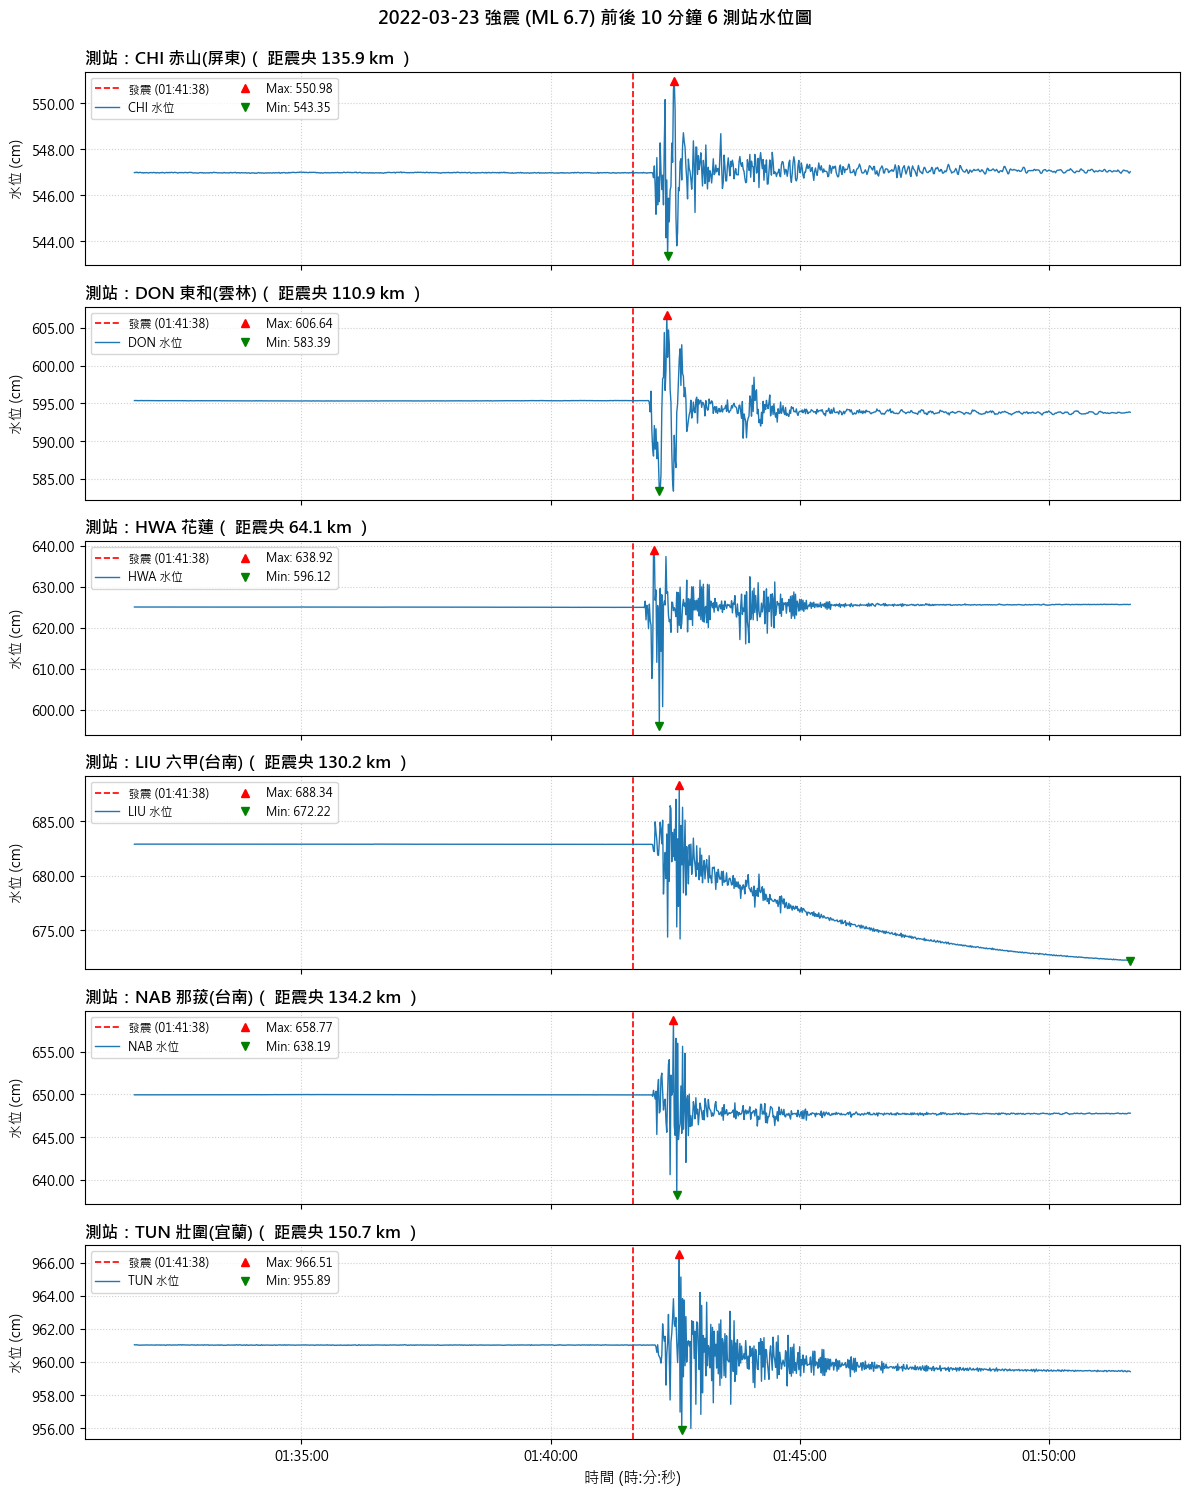


================ 📊 2022-03-23 強震 地下水位同震波幅統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (cm),最高 (cm),最低 (cm),最大全振幅 (cm),最大向上偏移,最大向下偏移
CHI,赤山(屏東),135.900000,546.980000,550.980000,543.350000,7.630000,4.000000,-3.630000
DON,東和(雲林),110.900000,595.350000,606.640000,583.390000,23.250000,11.290000,-11.960000
HWA,花蓮,64.100000,625.010000,638.920000,596.120000,42.800000,13.910000,-28.890000
LIU,六甲(台南),130.200000,682.890000,688.340000,672.220000,16.120000,5.450000,-10.670000
NAB,那菝(台南),134.200000,649.960000,658.770000,638.190000,20.580000,8.810000,-11.770000
TUN,壯圍(宜蘭),150.700000,961.020000,966.510000,955.890000,10.620000,5.490000,-5.130000


In [7]:
# ======================================================================
# 📌 第四大地震：2022-03-23 台東長濱地震 (ML 6.70, 01:41:38)
# ======================================================================

# 2022-03-23 前後 10 分鐘 6 測站地下水位變化與動態波幅統計
plot_seismic_event(rank=4, feature="water_level", mode="zoom", window_min=10, calc_stats=True)

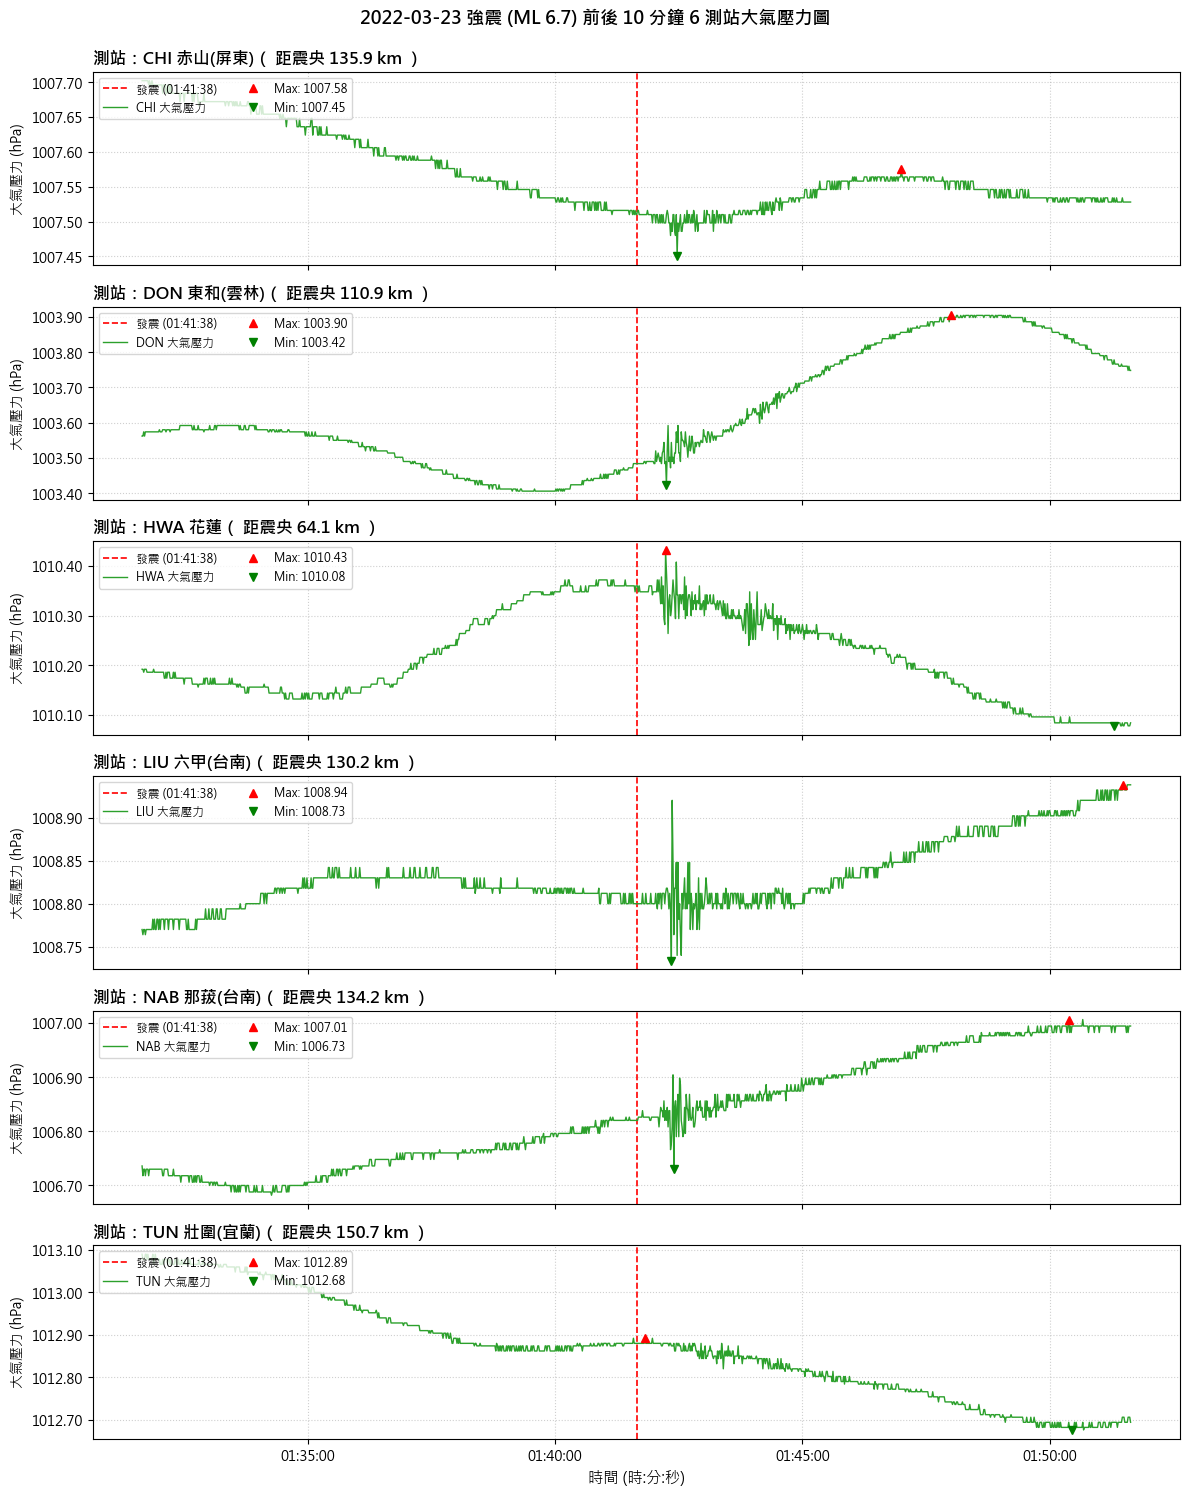


================ 📊 2022-03-23 強震 大氣壓力波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (hPa),最高 (hPa),最低 (hPa),最大全振幅 (hPa),最大向上偏移,最大向下偏移
CHI,赤山(屏東),135.900000,1007.550000,1007.580000,1007.450000,0.130000,0.020000,-0.100000
DON,東和(雲林),110.900000,1003.440000,1003.900000,1003.420000,0.480000,0.460000,-0.020000
HWA,花蓮,64.100000,1010.300000,1010.430000,1010.080000,0.350000,0.130000,-0.220000
LIU,六甲(台南),130.200000,1008.820000,1008.940000,1008.730000,0.200000,0.120000,-0.090000
NAB,那菝(台南),134.200000,1006.780000,1007.010000,1006.730000,0.280000,0.230000,-0.050000
TUN,壯圍(宜蘭),150.700000,1012.880000,1012.890000,1012.680000,0.220000,0.010000,-0.210000


In [9]:
# 2022-03-23 前後 10 分鐘 6 測站大氣壓力波動標示與統計
plot_seismic_event(rank=4, feature="pressure", mode="zoom", window_min=10, calc_stats=True)

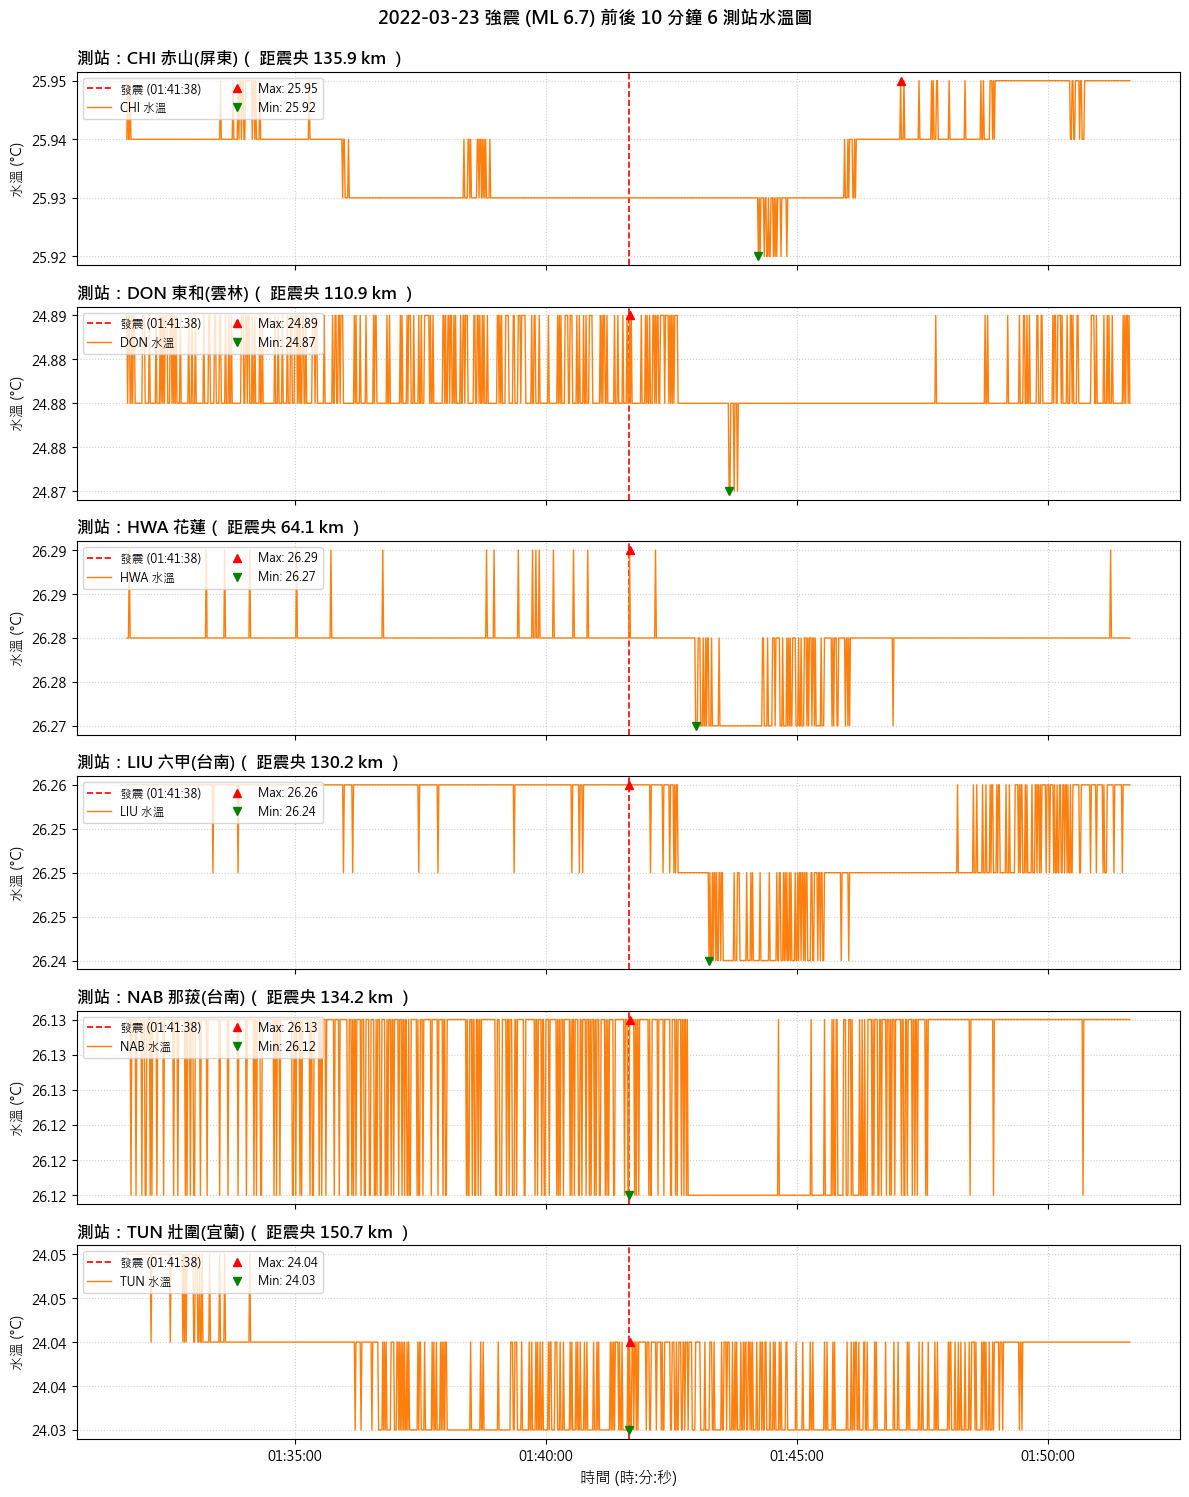


================ 📊 2022-03-23 強震 水溫波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (°C),最高 (°C),最低 (°C),最大全振幅 (°C),最大向上偏移,最大向下偏移
CHI,赤山(屏東),135.900000,25.930000,25.950000,25.920000,0.030000,0.020000,-0.010000
DON,東和(雲林),110.900000,24.880000,24.890000,24.870000,0.020000,0.010000,-0.010000
HWA,花蓮,64.100000,26.280000,26.290000,26.270000,0.020000,0.010000,-0.010000
LIU,六甲(台南),130.200000,26.260000,26.260000,26.240000,0.020000,0.000000,-0.020000
NAB,那菝(台南),134.200000,26.130000,26.130000,26.120000,0.010000,0.000000,-0.010000
TUN,壯圍(宜蘭),150.700000,24.030000,24.040000,24.030000,0.010000,0.010000,-0.000000


In [11]:
# 2022-03-23 前後 10 分鐘水溫變化圖(上水溫 (upper_temp))
plot_seismic_event(rank=4, feature="upper_temp", mode="zoom", window_min=10, calc_stats=True)

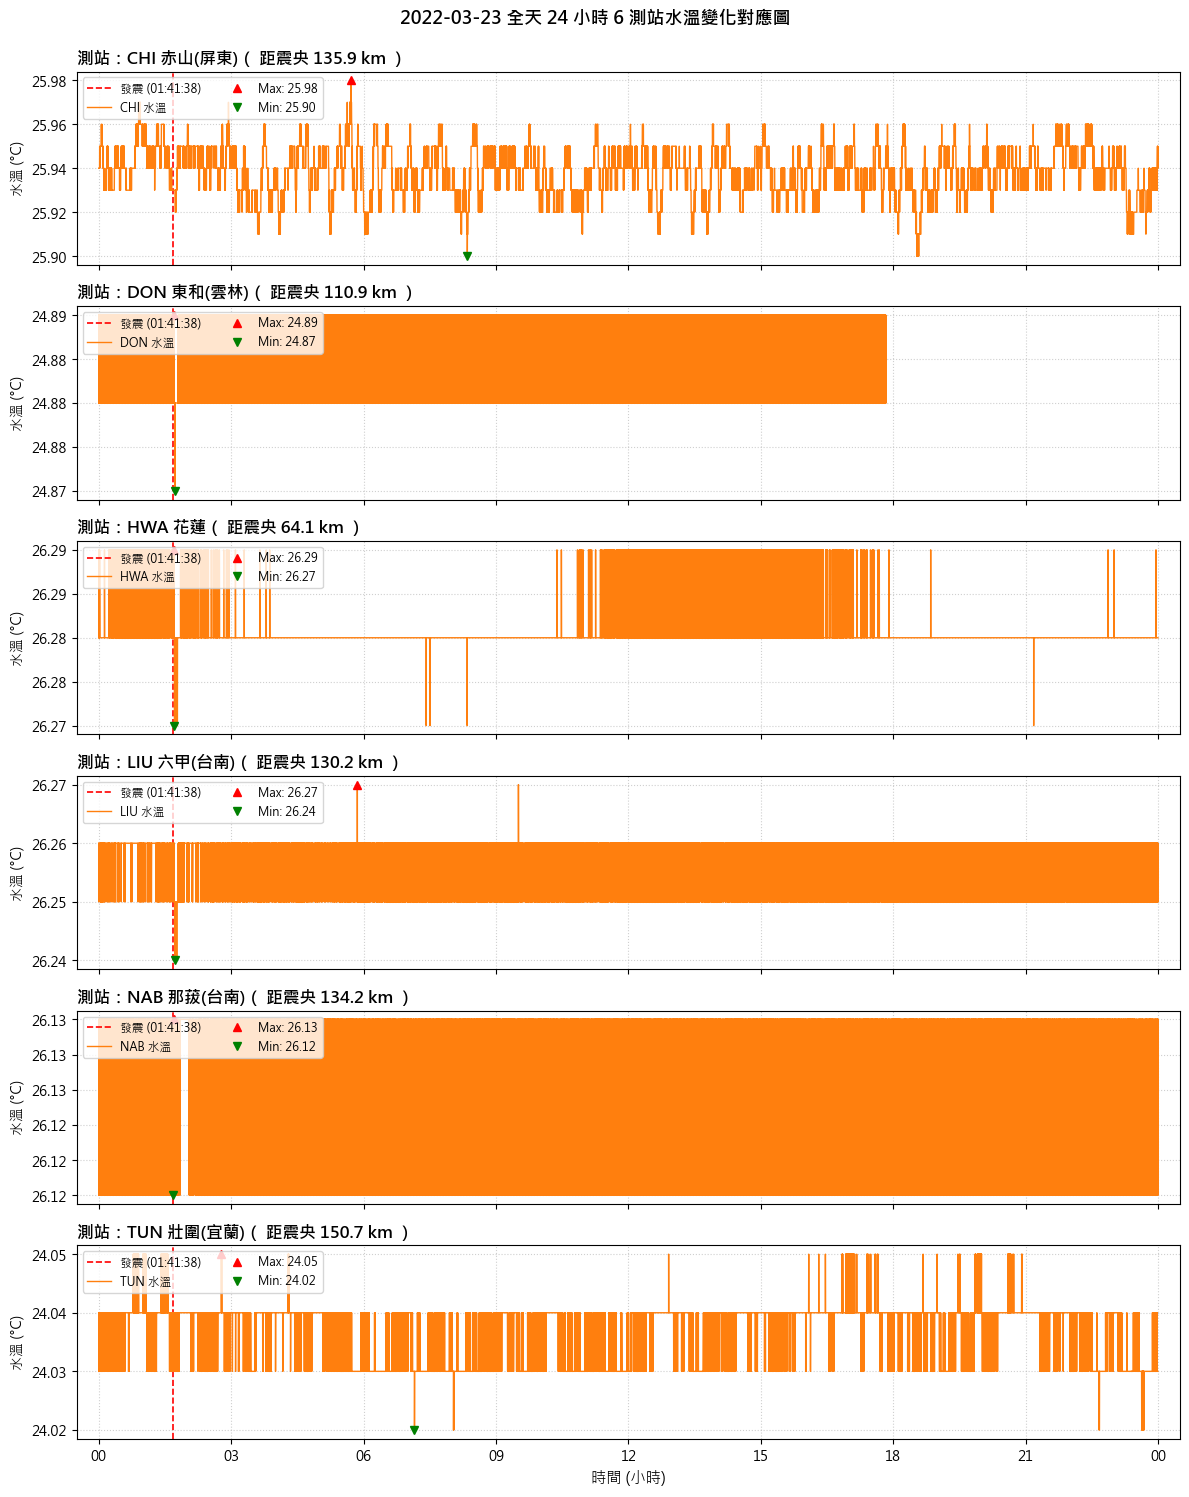


================ 📊 2022-03-23 強震 水溫波動統計表 ================


測站代碼,測站名稱,距震央距離 (km),震前基準 (°C),最高 (°C),最低 (°C),最大全振幅 (°C),最大向上偏移,最大向下偏移
CHI,赤山(屏東),135.900000,25.930000,25.980000,25.900000,0.080000,0.050000,-0.030000
DON,東和(雲林),110.900000,24.880000,24.890000,24.870000,0.020000,0.010000,-0.010000
HWA,花蓮,64.100000,26.280000,26.290000,26.270000,0.020000,0.010000,-0.010000
LIU,六甲(台南),130.200000,26.260000,26.270000,26.240000,0.030000,0.010000,-0.020000
NAB,那菝(台南),134.200000,26.130000,26.130000,26.120000,0.010000,0.000000,-0.010000
TUN,壯圍(宜蘭),150.700000,24.030000,24.050000,24.020000,0.030000,0.020000,-0.010000


In [13]:
# 2022-03-23 全天 24 小時 6 測站水溫變化圖(上水溫 (upper_temp))
plot_seismic_event(rank=4, feature="upper_temp", mode="day", calc_stats=True)